In [11]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pillow",
    "tqdm",
    "pyyaml",
    "timm",
    "captum",
    "wandb",
]

missing = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg.replace('-', '_')) is None]
if missing:
    result = subprocess.run(["/Users/yashchourasia/Desktop/dissertation/yc432/.venv/bin/python", "-m", "pip", "install", "-q"] + missing)
    if result.returncode == 0:
        print("Installed missing packages:", ", ".join(missing))
    else:
        print("Failed to install missing packages:", ", ".join(missing))
else:
    print("All required notebook dependencies already installed")



Installed missing packages: numpy, pandas, matplotlib, seaborn, scikit-learn, pillow, tqdm, pyyaml, timm, captum, wandb


In [12]:
import os
import random
import json
import hashlib
import pathlib
import sys

sys.path.insert(0, '/Users/yashchourasia/Desktop/dissertation/yc432/.venv/lib/python3.14/site-packages')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import timm
import captum
import sklearn

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"timm: {timm.__version__}")
print(f"captum: {captum.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.14.3
NumPy: 1.26.4
Pandas: 2.3.3
Matplotlib: 3.10.8
PyTorch: 2.10.0
torchvision: 0.25.0
timm: 1.0.25
captum: 0.8.0
scikit-learn: 1.8.0


In [13]:
GLOBAL_SEED = 42

def set_seed(seed: int = GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"All seeds set to {seed}")

set_seed(GLOBAL_SEED)

All seeds set to 42


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    mem = getattr(props, "total_memory", None) or getattr(props, "total_mem", None)
    print(f"GPU Memory: {mem / 1e9:.2f} GB")

Device: cpu


In [16]:
import os
import pathlib

# Resolve project root robustly across local machines / Colab / Codespaces
if "PROJECT_ROOT" in os.environ:
    PROJECT_ROOT = pathlib.Path(os.environ["PROJECT_ROOT"]).expanduser().resolve()
elif "__file__" in globals():
    PROJECT_ROOT = pathlib.Path(__file__).resolve().parent
else:
    PROJECT_ROOT = pathlib.Path.cwd().resolve()

if (PROJECT_ROOT / "yc432").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "yc432").resolve()

DATA_CANDIDATES = [
    pathlib.Path(os.environ.get("EUROSAT_DIR", "")).expanduser() if os.environ.get("EUROSAT_DIR") else None,
    PROJECT_ROOT / "data" / "archive (1)" / "EuroSAT",
    PROJECT_ROOT / "data" / "archive" / "EuroSAT",
    PROJECT_ROOT / "data" / "EuroSAT",
    PROJECT_ROOT / "data" / "2750",
    PROJECT_ROOT / "EuroSAT",
]
DATA_CANDIDATES = [p.resolve() for p in DATA_CANDIDATES if p is not None]

DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), None)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_ROOT}")

if DATA_DIR is None:
    checked = "\n".join(str(p) for p in DATA_CANDIDATES)
    raise FileNotFoundError(
        "Dataset folder not found. Set EUROSAT_DIR or place the dataset in one of these paths:\n"
        f"{checked}"
    )

for d in [
    "configs",
    "data/splits",
    "data/eda",
    "src",
    "src/data",
    "src/models",
    "src/xai",
    "src/evaluation",
    "src/utils",
    "checkpoints",
    "results/metrics",
    "results/figures",
    "results/heatmaps",
    "results/failure_cases",
    "notebooks",
    "tests",
    "logs",
]:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

for d in ["src", "src/data", "src/models", "src/xai", "src/evaluation", "src/utils"]:
    (PROJECT_ROOT / d / "__init__.py").touch(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_DIR}")

class_folders = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir() and not p.name.startswith(".")])
print(f"Found {len(class_folders)} class folders")
print("Classes:", class_folders)
print("Project directories ready")




Project root: /Users/yashchourasia/Desktop/dissertation/yc432
Dataset path: /Users/yashchourasia/Desktop/dissertation/yc432/data/2750
Found 10 class folders
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Project directories ready


In [17]:
import yaml

config = {
    "project": {
        "name": "coloring-black-boxes",
        "author": "Yash Chourasia",
        "student_id": "249015981",
        "email": "yc432@student.le.ac.uk",
        "seed": GLOBAL_SEED,
    },
    "data": {
        "dataset": "EuroSAT",
        "data_dir": str(DATA_DIR),
        "splits_dir": str(PROJECT_ROOT / "data" / "splits"),
        "num_classes": 10,
        "image_size": 64,
        "channels": 3,
        "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
        "split_seed": GLOBAL_SEED,
    },
    "augmentation": {
        "train": {
            "random_horizontal_flip": 0.5,
            "random_vertical_flip": 0.5,
            "random_rotation_degrees": 15,
            "color_jitter": {
                "brightness": 0.2,
                "contrast": 0.2,
                "saturation": 0.1,
                "hue": 0.05,
            },
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
        "eval": {
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
    },
    "training": {
        "resnet18": {
            "pretrained": True,
            "pretrained_source": "torchvision_imagenet1k",
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 0,
        },
        "vit_tiny": {
            "pretrained": True,
            "pretrained_source": "timm_imagenet21k",
            "model_name": "vit_tiny_patch16_224",
            "patch_size": 16,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 0,
        },
        "vim": {
            "pretrained": False,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "lr_fallback": 1e-5,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "warmup_epochs": 5,
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 0,
            "fp16": True,
        },
    },
    "xai": {
        "integrated_gradients": {"n_steps": 50, "baseline": "zero"},
        "smoothgrad": {"n_samples": 50, "noise_sigma_fraction": 0.1},
        "gradcam": {"target_layer": "layer4", "upsample_size": [64, 64]},
        "attention_rollout": {"discard_ratio": 0.0},
    },
    "evaluation": {
        "n_test_images": 200,
        "insertion_deletion_steps": 20,
        "stability_noise_levels": [0.01, 0.05, 0.1],
        "sensitivity_top_k_fraction": 0.20,
        "min_failure_patterns": 3,
    },
}

config_path = PROJECT_ROOT / "configs" / "master_config.yaml"
with open(config_path, "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Master config saved to: {config_path}")


Master config saved to: /Users/yashchourasia/Desktop/dissertation/yc432/configs/master_config.yaml


In [18]:
import pandas as pd

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])

CLASS_NAMES = [d.name for d in class_dirs]
NUM_CLASSES = len(CLASS_NAMES)

assert NUM_CLASSES == 10, f"Expected 10 classes, found {NUM_CLASSES}"

file_records = []

for class_dir in class_dirs:
    class_name = class_dir.name

    image_files = [
        f for f in class_dir.rglob("*")
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    print(f"{class_name}: {len(image_files)} images found")

    for img_path in image_files:
        file_records.append({
            "filepath": str(img_path),
            "filename": img_path.name,
            "class_name": class_name,
            "class_idx": CLASS_NAMES.index(class_name),
        })

df_all = pd.DataFrame(file_records)
total_images = len(df_all)

assert total_images > 0, "No images found in DATA_DIR"

print(f"Total images: {total_images}")
print(f"Classes: {NUM_CLASSES}")
print("\nClass distribution:")
print(df_all["class_name"].value_counts().sort_index())

AnnualCrop: 3000 images found
Forest: 3000 images found
HerbaceousVegetation: 3000 images found
Highway: 2500 images found
Industrial: 2500 images found
Pasture: 2000 images found
PermanentCrop: 2500 images found
Residential: 3000 images found
River: 2500 images found
SeaLake: 3000 images found
Total images: 27000
Classes: 10

Class distribution:
class_name
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64


In [19]:
print("Verifying image properties (sampling 100 images)...")

sample_paths = df_all["filepath"].sample(n=100, random_state=GLOBAL_SEED).tolist()

sizes = []
modes = []
corrupt_files = []

for pth in sample_paths:
    try:
        img = Image.open(pth)
        img.verify()
        img = Image.open(pth)
        sizes.append(img.size)
        modes.append(img.mode)
    except Exception as e:
        corrupt_files.append((pth, str(e)))

unique_sizes = set(sizes)
unique_modes = set(modes)

print(f"  Unique sizes: {unique_sizes}")
print(f"  Unique modes: {unique_modes}")
print(f"  Corrupt files: {len(corrupt_files)}")

if corrupt_files:
    print("  Corrupt files:")
    for path, err in corrupt_files[:10]:
        print(f"    {path}: {err}")
else:
    print("All sampled images are valid")

assert unique_sizes == {(64, 64)}, f"Unexpected image sizes found: {unique_sizes}"
assert unique_modes == {"RGB"}, f"Unexpected image modes found: {unique_modes}"
print("Image verification passed")

Verifying image properties (sampling 100 images)...
  Unique sizes: {(64, 64)}
  Unique modes: {'RGB'}
  Corrupt files: 0
All sampled images are valid
Image verification passed


In [20]:
split_ratios = config["data"]["split_ratios"]
split_seed = config["data"]["split_seed"]

df_train, df_temp = train_test_split(
    df_all,
    test_size=(split_ratios["val"] + split_ratios["test"]),
    random_state=split_seed,
    stratify=df_all["class_idx"],
)

val_fraction = split_ratios["val"] / (split_ratios["val"] + split_ratios["test"])
df_val, df_test = train_test_split(
    df_temp,
    test_size=(1 - val_fraction),
    random_state=split_seed,
    stratify=df_temp["class_idx"],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Split sizes:")
print(f"  Train: {len(df_train)} ({100 * len(df_train) / total_images:.1f}%)")
print(f"  Val:   {len(df_val)} ({100 * len(df_val) / total_images:.1f}%)")
print(f"  Test:  {len(df_test)} ({100 * len(df_test) / total_images:.1f}%)")
print(f"  Total: {len(df_train) + len(df_val) + len(df_test)}")

train_files = set(df_train["filepath"])
val_files = set(df_val["filepath"])
test_files = set(df_test["filepath"])

assert len(train_files & val_files) == 0, "LEAKAGE: train ∩ val"
assert len(train_files & test_files) == 0, "LEAKAGE: train ∩ test"
assert len(val_files & test_files) == 0, "LEAKAGE: val ∩ test"
assert len(train_files | val_files | test_files) == total_images, "Missing images!"

print("No data leakage detected")
print("All images accounted for")

Split sizes:
  Train: 18900 (70.0%)
  Val:   4050 (15.0%)
  Test:  4050 (15.0%)
  Total: 27000
No data leakage detected
All images accounted for


In [21]:
splits_dir = PROJECT_ROOT / "data" / "splits"

df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

class_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
with open(splits_dir / "class_mapping.json", "w") as f:
    json.dump(class_map, f, indent=2)

def split_hash(df: pd.DataFrame) -> str:
    content = "\n".join(sorted(df["filepath"].tolist()))
    return hashlib.sha256(content.encode()).hexdigest()[:16]

hashes = {
    "train": split_hash(df_train),
    "val": split_hash(df_val),
    "test": split_hash(df_test),
    "seed": GLOBAL_SEED,
}

with open(splits_dir / "split_hashes.json", "w") as f:
    json.dump(hashes, f, indent=2)

print(f"Split CSVs saved to: {splits_dir}")
print(f"Class mapping: {class_map}")
print("\nReproducibility hashes:")
for k, v in hashes.items():
    print(f"  {k}: {v}")
print("\nRe-run anytime — if hashes match, splits are identical")

Split CSVs saved to: /Users/yashchourasia/Desktop/dissertation/yc432/data/splits
Class mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Reproducibility hashes:
  train: d45f05217b5fbd2b
  val: 11e0935a15995137
  test: f6d60a70c3b8b5ac
  seed: 42

Re-run anytime — if hashes match, splits are identical


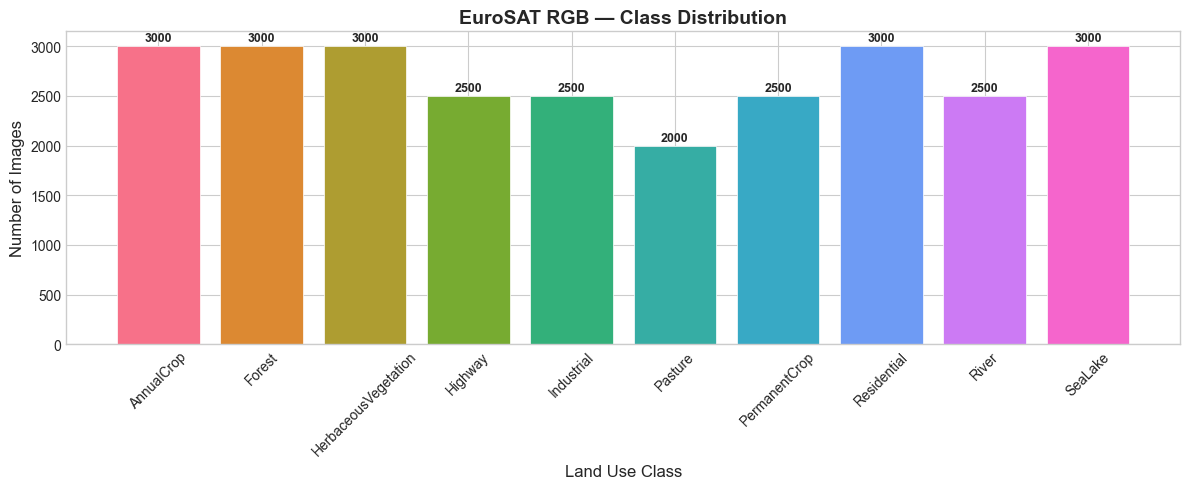

Class distribution plot saved


In [22]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))
counts = df_all["class_name"].value_counts().sort_index()
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Land Use Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("EuroSAT RGB — Class Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution plot saved")

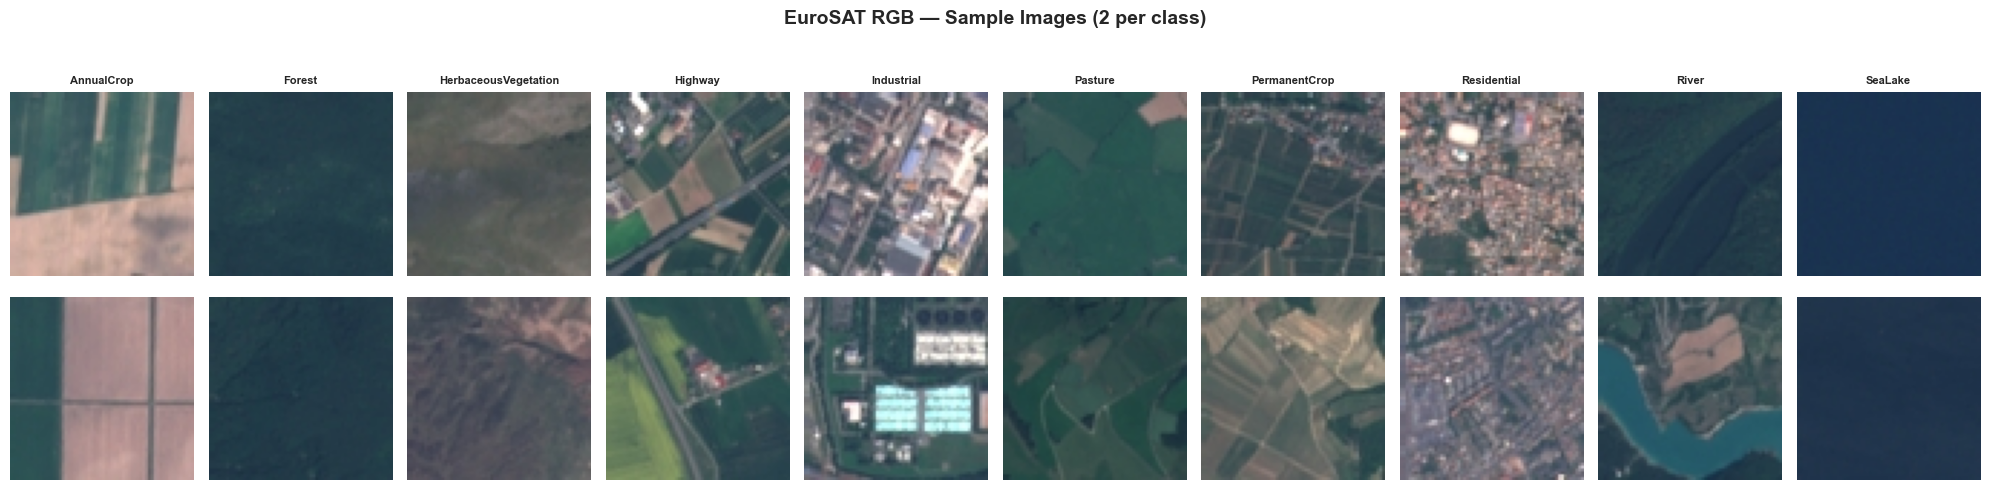

Sample images grid saved


In [23]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 5))
fig.suptitle("EuroSAT RGB — Sample Images (2 per class)", fontsize=14, fontweight="bold", y=1.02)

for col_idx, class_name in enumerate(CLASS_NAMES):
    class_df = df_all[df_all["class_name"] == class_name].sample(n=2, random_state=GLOBAL_SEED)
    for row_idx, (_, row) in enumerate(class_df.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(class_name, fontsize=8, fontweight="bold")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "sample_images_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images grid saved")

In [25]:
from torchvision import transforms

print("Computing per-channel statistics...")

to_tensor = transforms.ToTensor()

sample_df = df_all.groupby("class_name", group_keys=False).apply(
    lambda x: x.sample(n=min(100, len(x)), random_state=GLOBAL_SEED)
).reset_index(drop=True)

pixel_sum = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
n_pixels = 0

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Stats"):
    img = Image.open(row["filepath"]).convert("RGB")
    tensor = to_tensor(img)
    pixel_sum += tensor.sum(dim=[1, 2])
    pixel_sq_sum += (tensor ** 2).sum(dim=[1, 2])
    n_pixels += tensor.shape[1] * tensor.shape[2]

dataset_mean = pixel_sum / n_pixels
dataset_std = torch.sqrt(pixel_sq_sum / n_pixels - dataset_mean ** 2)

print("\nEuroSAT RGB channel statistics:")
print(f"Mean: R={dataset_mean[0]:.4f}, G={dataset_mean[1]:.4f}, B={dataset_mean[2]:.4f}")
print(f"Std : R={dataset_std[0]:.4f}, G={dataset_std[1]:.4f}, B={dataset_std[2]:.4f}")

print("\nImageNet normalization (used for pretrained models)")
print("Mean: [0.485, 0.456, 0.406]")
print("Std : [0.229, 0.224, 0.225]")

channel_stats = {
    "eurosat_mean": dataset_mean.tolist(),
    "eurosat_std": dataset_std.tolist(),
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
    "n_images_sampled": len(sample_df),
}

with open(PROJECT_ROOT / "data" / "eda" / "channel_statistics.json", "w") as f:
    json.dump(channel_stats, f, indent=2)

print("Channel statistics saved")

/var/folders/37/64m01k5n3lv5dbjgsndhmlw40000gn/T/ipykernel_16018/1321152360.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_all.groupby("class_name", group_keys=False).apply(


Computing per-channel statistics...


Stats: 100%|██████████| 1000/1000 [00:00<00:00, 8976.02it/s]


EuroSAT RGB channel statistics:
Mean: R=0.3397, G=0.3788, B=0.4066
Std : R=0.1990, G=0.1346, B=0.1142

ImageNet normalization (used for pretrained models)
Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]
Channel statistics saved


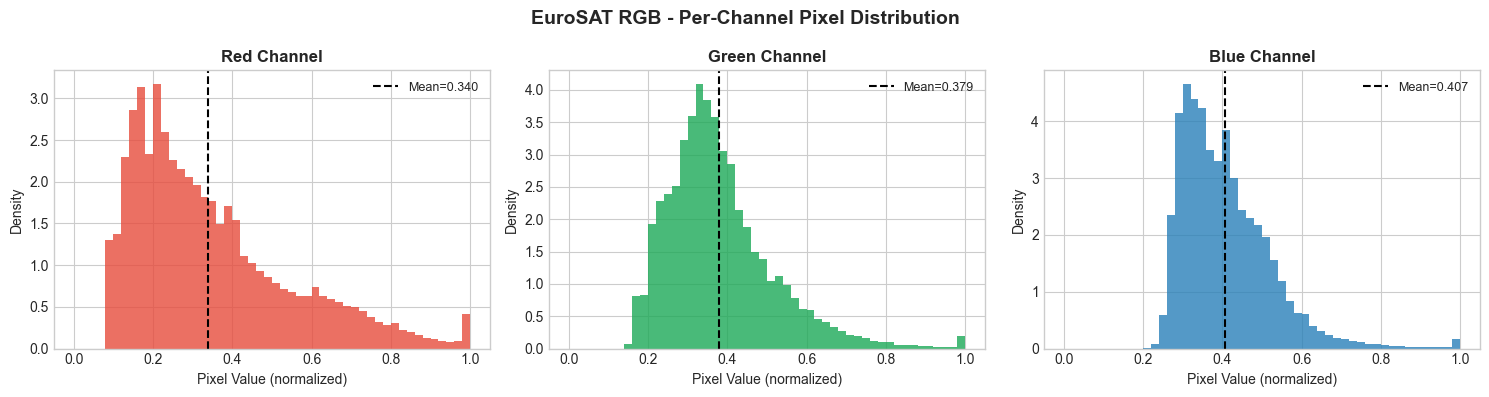

Channel histograms saved


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ["Red", "Green", "Blue"]
channel_colors = ["#e74c3c", "#1ca957", "#2980b9"]

all_pixels = {c: [] for c in range(3)}
for _, row in sample_df.sample(200, random_state=GLOBAL_SEED).iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    tensor = to_tensor(img)
    for c in range(3):
        all_pixels[c].append(tensor[c].flatten().numpy())

# Use fixed bin edges for numerical stability across numpy/matplotlib versions
bins = np.linspace(0.0, 1.0, 51)
for c in range(3):
    channel_vals = np.concatenate(all_pixels[c]).astype(np.float32)
    channel_vals = channel_vals[np.isfinite(channel_vals)]
    axes[c].hist(channel_vals, bins=bins, color=channel_colors[c], alpha=0.8, density=True)
    axes[c].set_title(f"{channel_names[c]} Channel", fontsize=12, fontweight="bold")
    axes[c].set_xlabel("Pixel Value (normalized)")
    axes[c].set_ylabel("Density")
    axes[c].axvline(dataset_mean[c].item(), color="black", linestyle="--", linewidth=1.5,
                    label=f"Mean={dataset_mean[c]:.3f}")
    axes[c].legend(fontsize=9)

fig.suptitle("EuroSAT RGB - Per-Channel Pixel Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "channel_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Channel histograms saved")



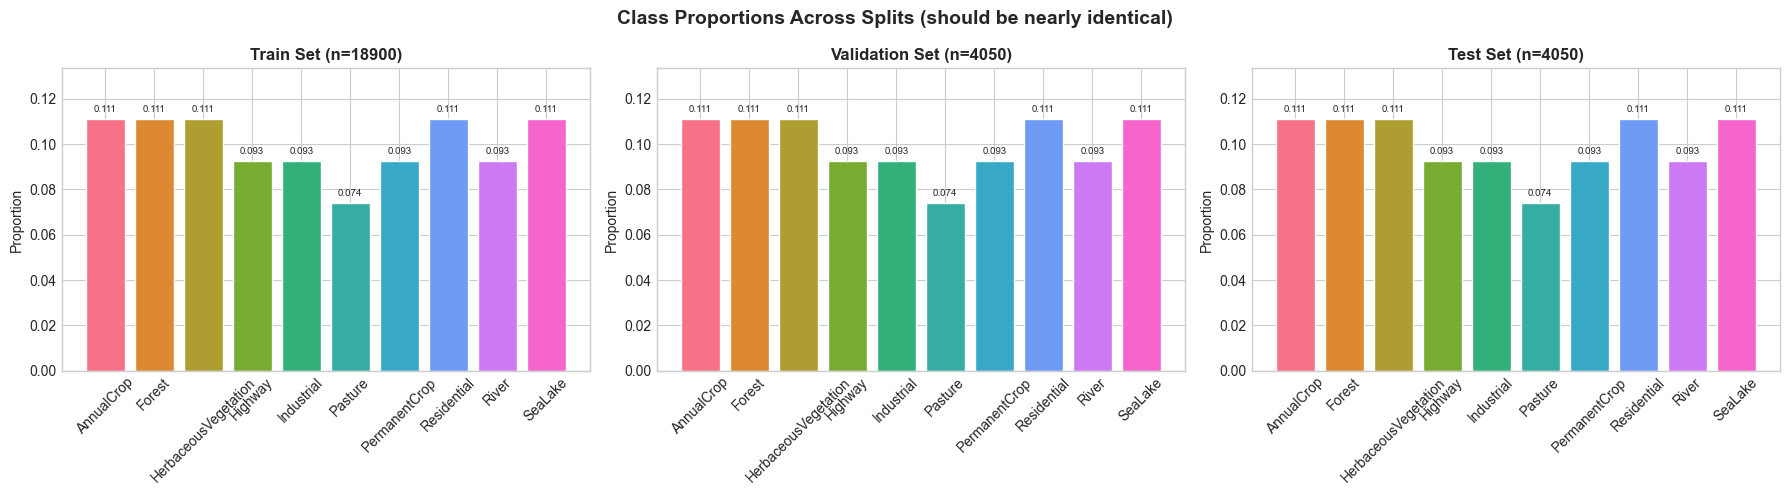

Max proportion drift between train and test: 0.0000
Stratification verified


In [27]:
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
split_names = ["Train", "Validation", "Test"]
split_dfs = [df_train, df_val, df_test]

for ax, name, df_split in zip(axes, split_names, split_dfs):
    counts_s = df_split["class_name"].value_counts().sort_index()
    proportions = counts_s / counts_s.sum()
    bars = ax.bar(proportions.index, proportions.values, color=colors, edgecolor="white")
    ax.set_title(f"{name} Set (n={len(df_split)})", fontsize=12, fontweight="bold")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, max(proportions.values) * 1.2)
    for bar, prop in zip(bars, proportions.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{prop:.3f}", ha="center", va="bottom", fontsize=7)

fig.suptitle("Class Proportions Across Splits (should be nearly identical)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "split_stratification_check.png", dpi=150, bbox_inches="tight")
plt.show()

train_props = df_train["class_name"].value_counts(normalize=True).sort_index()
test_props = df_test["class_name"].value_counts(normalize=True).sort_index()
max_drift = (train_props - test_props).abs().max()
print(f"Max proportion drift between train and test: {max_drift:.4f}")
assert max_drift < 0.02, "Stratification failed — drift too large"
print("Stratification verified")

In [28]:
import json
import pathlib
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ---- Paths ----
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = pathlib.Path(".")  # change only if your repo is elsewhere

splits_dir = PROJECT_ROOT / "data" / "splits"

train_csv = splits_dir / "train.csv"
val_csv = splits_dir / "val.csv"
if not val_csv.exists():
    val_csv = splits_dir / "validation.csv"  # fallback if file is named validation.csv

if not train_csv.exists() or not val_csv.exists():
    raise FileNotFoundError(f"Missing split files in {splits_dir}. Found: {list(splits_dir.glob('*.csv'))}")

df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

# label column
label_col = "class_idx" if "class_idx" in df_train.columns else "label"
if label_col not in df_train.columns:
    raise ValueError(f"No label column found. Columns: {df_train.columns.tolist()}")

# Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

class EuroSATDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        y = int(row[label_col])

        if self.transform is not None:
            img = self.transform(img)
        return img, y

train_dataset = EuroSATDataset(df_train, transform=train_transform)
val_dataset = EuroSATDataset(df_val, transform=eval_transform)

batch_size = 64
num_workers = 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory
)

print(f"train_loader ready: {len(train_loader)} batches")
print(f"val_loader ready:   {len(val_loader)} batches")



train_loader ready: 296 batches
val_loader ready:   64 batches


In [29]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Safe defaults if earlier cells were not run
if "config" in globals():
    num_classes = int(config.get("data", {}).get("num_classes", 10))
else:
    num_classes = 10

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Try pretrained; fallback to random init if download/network fails
try:
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    print("Loaded ImageNet pretrained weights")
except Exception as e:
    print(f"[!] Pretrained weights not available ({e}). Using weights=None.")
    model = resnet18(weights=None)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(f"ResNet-18 ready on {device}")
print(f"Final classifier: {model.fc}")


Loaded ImageNet pretrained weights
ResNet-18 ready on cpu
Final classifier: Linear(in_features=512, out_features=10, bias=True)


In [30]:
import os
import torch.optim as optim
import torch.nn as nn

EPOCHS = int(os.environ.get("EPOCHS", "20"))
criterion = nn.CrossEntropyLoss()

lr = config["training"]["resnet18"]["lr"] if "config" in globals() else 1e-4
wd = config["training"]["resnet18"]["weight_decay"] if "config" in globals() else 1e-2

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Training setup ready for {EPOCHS} epochs")




Training setup ready for 20 epochs


In [32]:
import torch


def _macro_f1_torch(y_true: torch.Tensor, y_pred: torch.Tensor, num_classes: int | None = None) -> float:
    y_true = y_true.view(-1).to(torch.long)
    y_pred = y_pred.view(-1).to(torch.long)

    if num_classes is None:
        max_cls = int(torch.max(torch.cat([y_true, y_pred])).item()) if y_true.numel() else 0
        num_classes = max_cls + 1

    f1_scores = []
    for c in range(num_classes):
        tp = ((y_true == c) & (y_pred == c)).sum().item()
        fp = ((y_true != c) & (y_pred == c)).sum().item()
        fn = ((y_true == c) & (y_pred != c)).sum().item()
        denom = (2 * tp) + fp + fn
        f1_scores.append(0.0 if denom == 0 else (2 * tp) / denom)

    return float(sum(f1_scores) / max(1, len(f1_scores)))


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    all_targets = []
    all_preds = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

        all_targets.append(targets.detach().cpu())
        all_preds.append(preds.detach().cpu())

    avg_loss = running_loss / max(1, total)
    acc = correct / max(1, total)
    num_classes = getattr(getattr(model, "fc", None), "out_features", None)
    f1 = _macro_f1_torch(torch.cat(all_targets), torch.cat(all_preds), num_classes=num_classes)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)

            running_loss += loss.item() * targets.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            all_targets.append(targets.detach().cpu())
            all_preds.append(preds.detach().cpu())

    avg_loss = running_loss / max(1, total)
    acc = correct / max(1, total)
    num_classes = getattr(getattr(model, "fc", None), "out_features", None)
    f1 = _macro_f1_torch(torch.cat(all_targets), torch.cat(all_preds), num_classes=num_classes)
    return avg_loss, acc, f1


print("train_one_epoch and evaluate are ready")



train_one_epoch and evaluate are ready


In [33]:
from pathlib import Path
import torch

# Training loop
force_retrain = True
if force_retrain:
    best_model_path = PROJECT_ROOT / "checkpoints" / "resnet18_best_10ep.pth"
    if best_model_path.exists():
        best_model_path.unlink()
        print(f"[✓] Removed existing checkpoint to force retrain\n")

history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

best_val_acc = 0.0
best_model_path = PROJECT_ROOT / "checkpoints" / "resnet18_best_10ep.pth"
best_model_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Starting training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_f1 = evaluate(
        model, val_loader, criterion, device
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"[✓] Saved best model -> {best_model_path}")

print(f"\n[✓] Training complete. Best val acc: {best_val_acc:.4f}")

[✓] Removed existing checkpoint to force retrain

Starting training for 20 epochs...

Epoch 01/20 | Train Loss 0.4014 Acc 0.8695 F1 0.8654 | Val Loss 0.1963 Acc 0.9360 F1 0.9344
[✓] Saved best model -> /Users/yashchourasia/Desktop/dissertation/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 02/20 | Train Loss 0.1906 Acc 0.9356 F1 0.9337 | Val Loss 0.1290 Acc 0.9583 F1 0.9568
[✓] Saved best model -> /Users/yashchourasia/Desktop/dissertation/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 03/20 | Train Loss 0.1431 Acc 0.9505 F1 0.9489 | Val Loss 0.1112 Acc 0.9637 F1 0.9621
[✓] Saved best model -> /Users/yashchourasia/Desktop/dissertation/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 04/20 | Train Loss 0.1206 Acc 0.9600 F1 0.9586 | Val Loss 0.0896 Acc 0.9733 F1 0.9723
[✓] Saved best model -> /Users/yashchourasia/Desktop/dissertation/yc432/checkpoints/resnet18_best_10ep.pth
Epoch 05/20 | Train Loss 0.1009 Acc 0.9647 F1 0.9635 | Val Loss 0.1034 Acc 0.9704 F1 0.9691
Epoch 06/20 | Train Loss 0

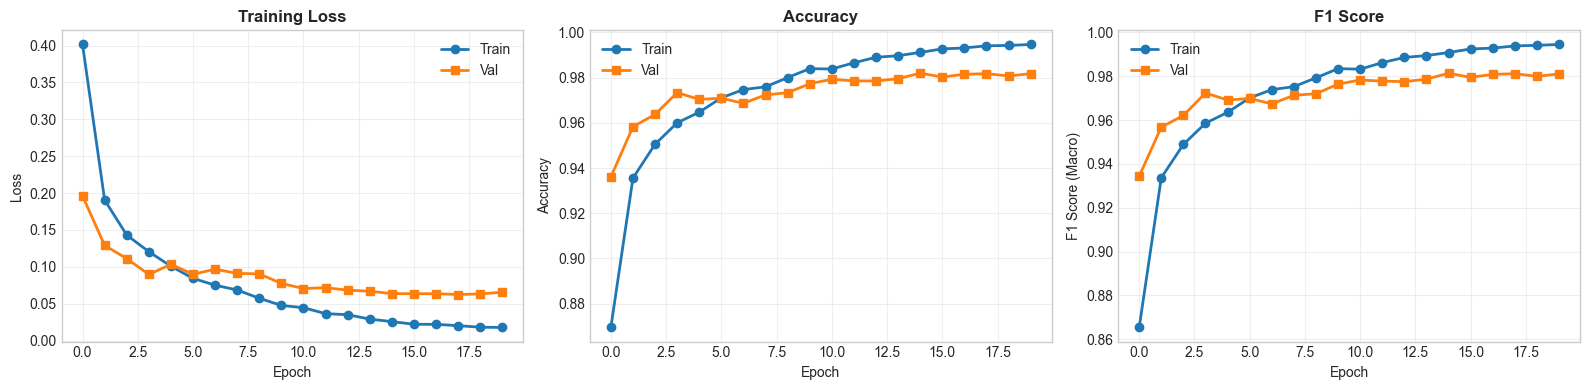

Training curves saved


In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train", marker='o', linewidth=2)
axes[0].plot(history["val_loss"], label="Val", marker='s', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss", fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history["train_acc"], label="Train", marker='o', linewidth=2)
axes[1].plot(history["val_acc"], label="Val", marker='s', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(history["train_f1"], label="Train", marker='o', linewidth=2)
axes[2].plot(history["val_f1"], label="Val", marker='s', linewidth=2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score (Macro)")
axes[2].set_title("F1 Score", fontweight='bold', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "figures" / "training_curves.png", dpi=200, bbox_inches='tight')
plt.show()
print("Training curves saved")

[✓] Recreated test_loader: 64 batches


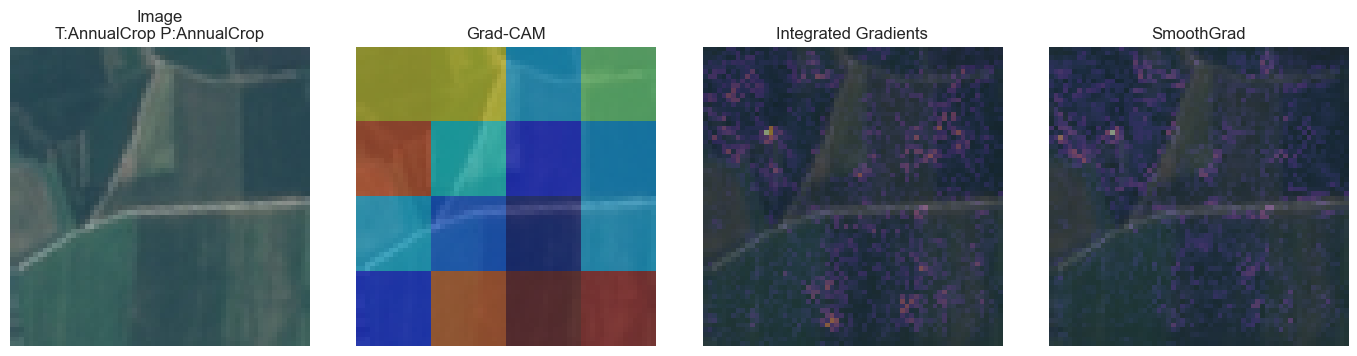

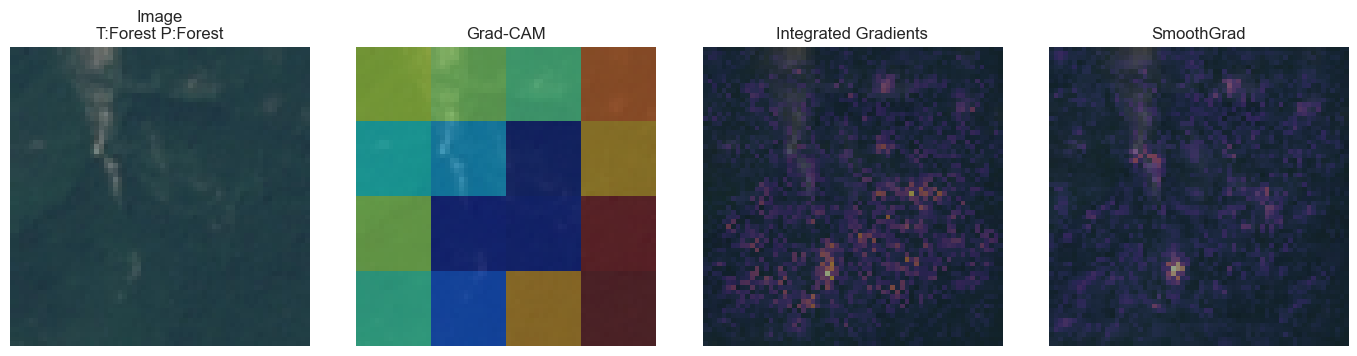

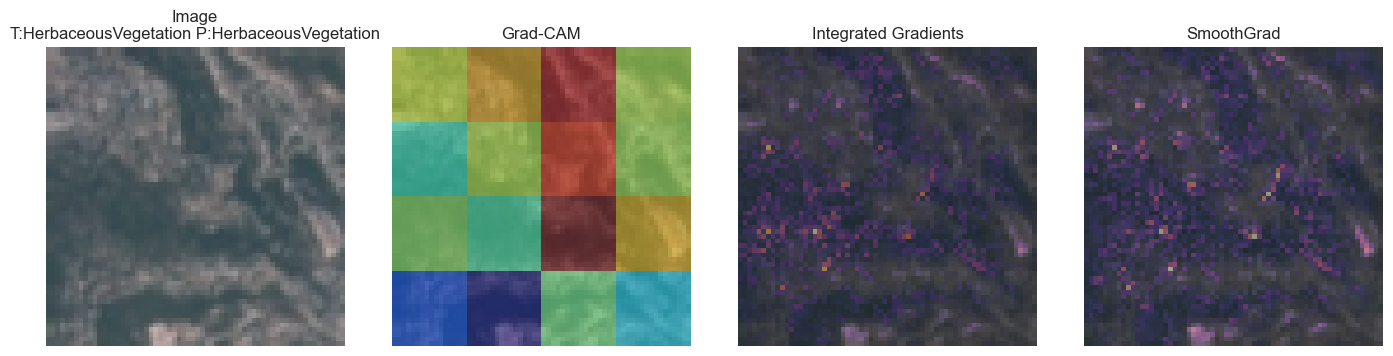

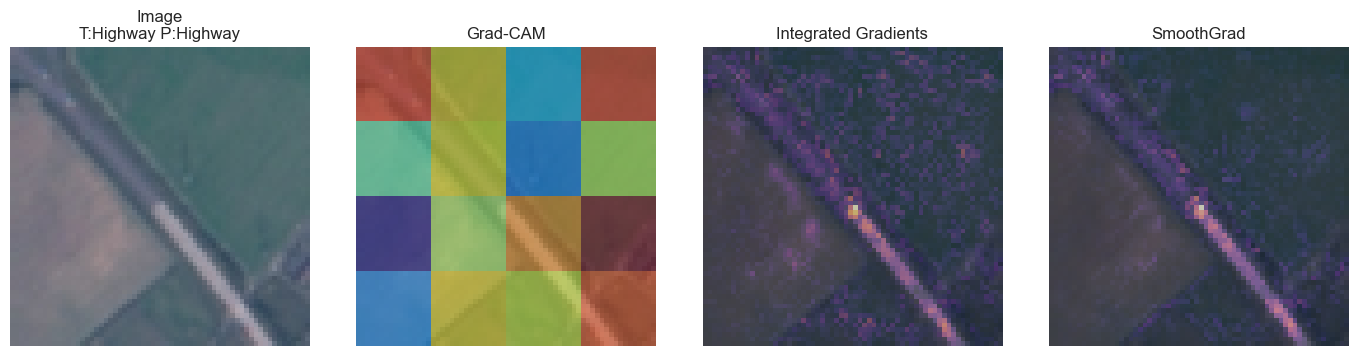

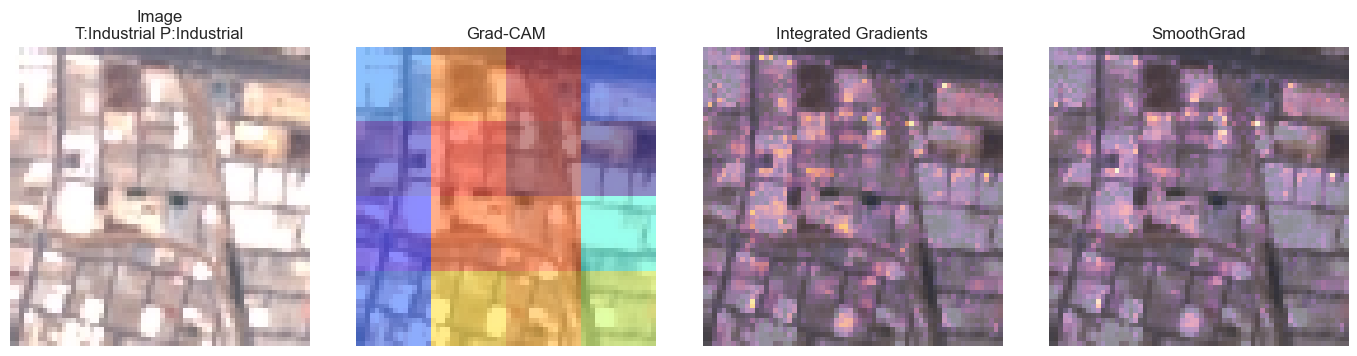

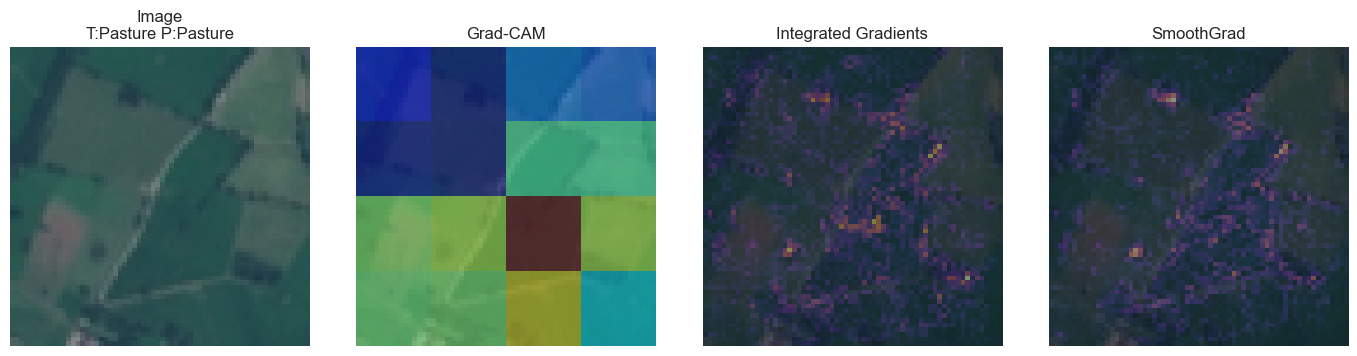

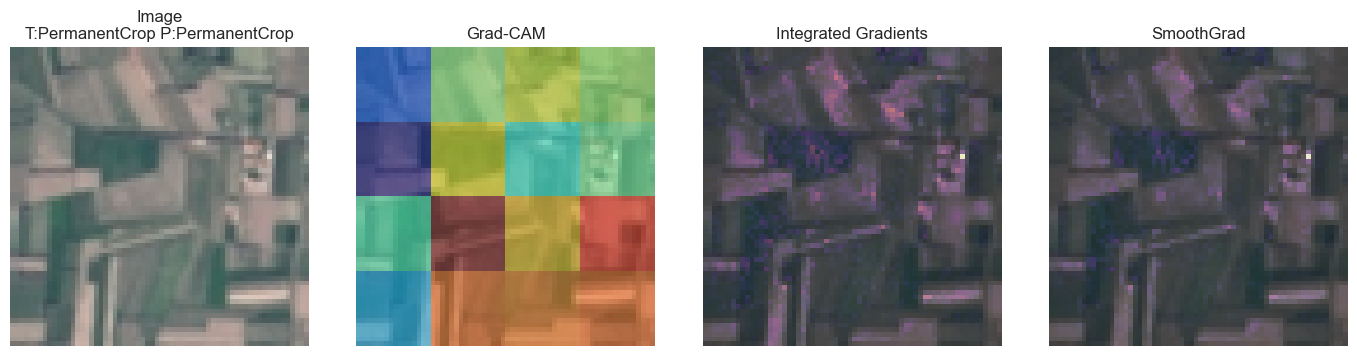

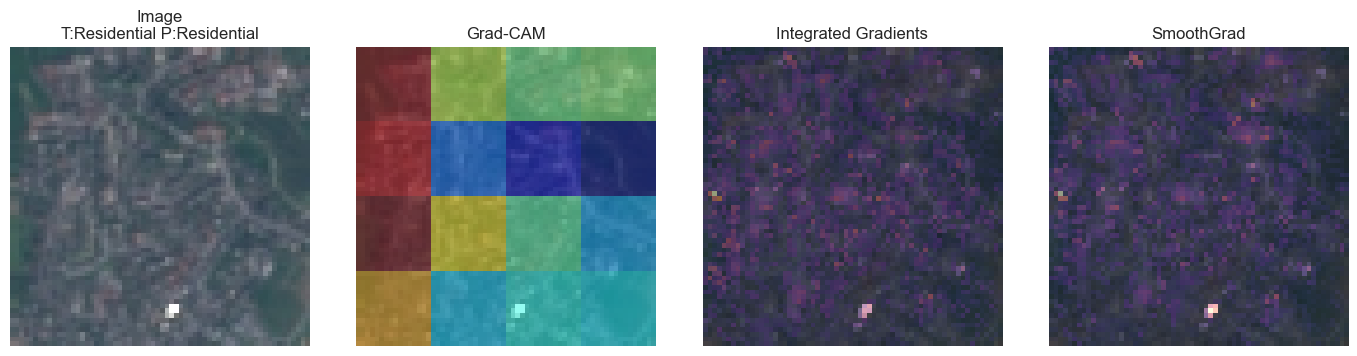

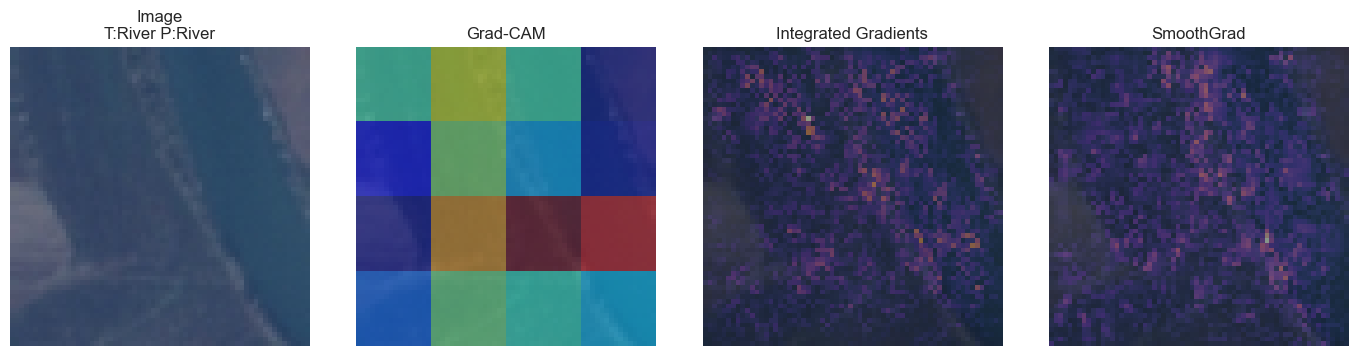

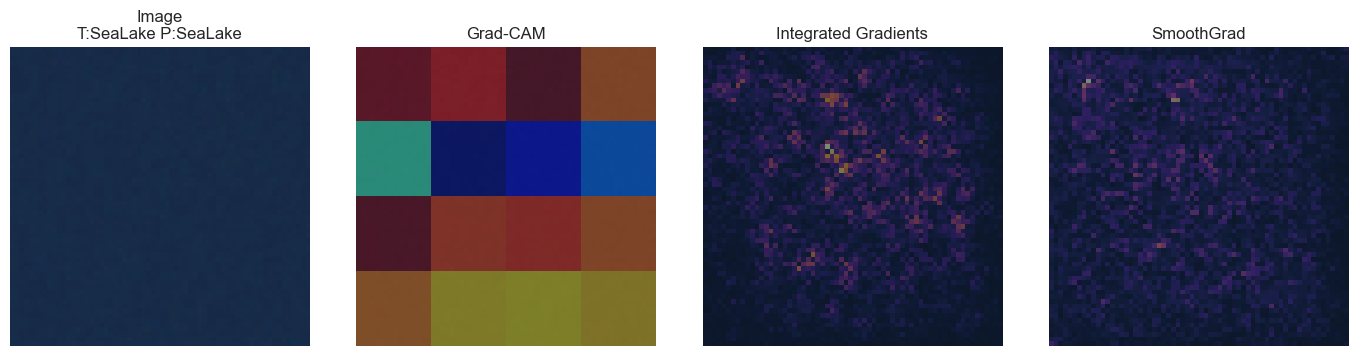

 Saved XAI heatmaps to: /Users/yashchourasia/Desktop/dissertation/yc432/results/heatmaps
Classes visualized (true labels): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [35]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from captum.attr import LayerGradCam, LayerAttribution, IntegratedGradients, NoiseTunnel

# ---------- checks ----------
required = ["model", "device", "test_loader", "PROJECT_ROOT"]
missing = [x for x in required if x not in globals()]
if missing:
    print(f"Warning: Missing required objects: {missing}. Attempting recovery...")

# ---------- recovery/setup ----------
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")  # change if needed

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "model" not in globals():
    from torchvision.models import resnet18, ResNet18_Weights
    import torch.nn as nn

    num_classes = 10
    try:
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    except Exception as e:
        print(f"[!] Pretrained weights not available ({e}). Using random init.")
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    best_model_path = PROJECT_ROOT / "checkpoints" / "resnet18_best_10ep.pth"
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"[✓] Loaded best model from: {best_model_path}")
    else:
        print(f"[!] No checkpoint found at {best_model_path}. Using untrained model.")

if "test_loader" not in globals():
    import pandas as pd
    from torch.utils.data import DataLoader, Dataset
    from torchvision import transforms
    from PIL import Image

    test_csv = PROJECT_ROOT / "data" / "splits" / "test.csv"
    if not test_csv.exists():
        raise FileNotFoundError(f"test.csv not found at: {test_csv}")

    df_test = pd.read_csv(test_csv)
    label_col = "class_idx" if "class_idx" in df_test.columns else "label"

    eval_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    class EuroSATTestDataset(Dataset):
        def __init__(self, df, transform):
            self.df = df.reset_index(drop=True)
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            x = Image.open(row["filepath"]).convert("RGB")
            y = int(row[label_col])
            return self.transform(x), y

    test_dataset = EuroSATTestDataset(df_test, eval_transform)
    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    print(f"[✓] Recreated test_loader: {len(test_loader)} batches")

model.eval()
PROJECT_ROOT = Path(PROJECT_ROOT)

# class names for display
class_names = None
class_map_path = PROJECT_ROOT / "data" / "splits" / "class_mapping.json"
if class_map_path.exists():
    with open(class_map_path, "r") as f:
        m = json.load(f)  # {"AnnualCrop":0,...}
    inv = {v: k for k, v in m.items()}
    class_names = [inv[i] for i in sorted(inv)]

# ---------- helpers ----------
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

def denorm(x):
    x = x * std + mean
    return torch.clamp(x, 0, 1)

def norm_map(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)

# ---------- collect ONE sample per true class ----------
num_classes = 10
one_per_class = {}

for batch_images, batch_labels in test_loader:
    for j in range(batch_labels.size(0)):
        cls = int(batch_labels[j].item())
        if cls not in one_per_class:
            one_per_class[cls] = batch_images[j:j+1]
        if len(one_per_class) == num_classes:
            break
    if len(one_per_class) == num_classes:
        break

missing_classes = sorted(set(range(num_classes)) - set(one_per_class.keys()))
if missing_classes:
    print(f"[!] Missing classes in collected samples: {missing_classes}")

ordered_classes = sorted(one_per_class.keys())
images = torch.cat([one_per_class[c] for c in ordered_classes], dim=0).to(device)
labels = torch.tensor(ordered_classes, device=device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1)

# ---------- explainers ----------
# For 64x64 input, layer3 gives less blocky maps than layer4
target_layer = model.layer3[-1].conv2
gradcam = LayerGradCam(model, target_layer)
ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)

save_dir = PROJECT_ROOT / "results" / "heatmaps"
save_dir.mkdir(parents=True, exist_ok=True)

K = images.size(0)

for i in range(K):
    x = images[i:i+1]
    pred_cls = int(preds[i].item())
    true_cls = int(labels[i].item())

    # Grad-CAM
    cam = gradcam.attribute(x, target=pred_cls)
    cam = LayerAttribution.interpolate(cam, (64, 64)).squeeze().detach().cpu().numpy()
    if cam.ndim == 3:
        cam = cam.mean(axis=0)
    cam = norm_map(cam)

    # Integrated Gradients
    baseline = torch.zeros_like(x)
    ig_attr = ig.attribute(x, baselines=baseline, target=pred_cls, n_steps=50)
    ig_map = ig_attr.squeeze().detach().cpu().numpy()
    ig_map = np.abs(ig_map).mean(axis=0)
    ig_map = norm_map(ig_map)

    # SmoothGrad (on IG)
    sg_attr = nt.attribute(
        x,
        nt_type="smoothgrad",
        nt_samples=25,
        stdevs=0.1,
        baselines=baseline,
        target=pred_cls,
        n_steps=25,
    )
    sg_map = sg_attr.squeeze().detach().cpu().numpy()
    sg_map = np.abs(sg_map).mean(axis=0)
    sg_map = norm_map(sg_map)

    img = denorm(x[0]).detach().cpu().permute(1, 2, 0).numpy()

    p_name = class_names[pred_cls] if class_names else str(pred_cls)
    t_name = class_names[true_cls] if class_names else str(true_cls)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    axes[0].imshow(img)
    axes[0].set_title(f"Image\nT:{t_name} P:{p_name}")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].imshow(cam, cmap="jet", alpha=0.45)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(img)
    axes[2].imshow(ig_map, cmap="inferno", alpha=0.45)
    axes[2].set_title("Integrated Gradients")
    axes[2].axis("off")

    axes[3].imshow(img)
    axes[3].imshow(sg_map, cmap="magma", alpha=0.45)
    axes[3].set_title("SmoothGrad")
    axes[3].axis("off")

    plt.tight_layout()
    out_path = save_dir / f"xai_trueclass_{true_cls:02d}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f" Saved XAI heatmaps to: {save_dir}")
print(f"Classes visualized (true labels): {ordered_classes}")



{
  "n_samples": 120,
  "faithfulness_mean_drop": 0.7885886523921869,
  "faithfulness_std": 0.37598267725848933,
  "stability_mean_cosine": 0.8694079210360844,
  "stability_std": 0.09369315190511415,
  "sensitivity_mean_top_minus_random": 0.044948498728864965,
  "sensitivity_std": 0.17851552807982662
}


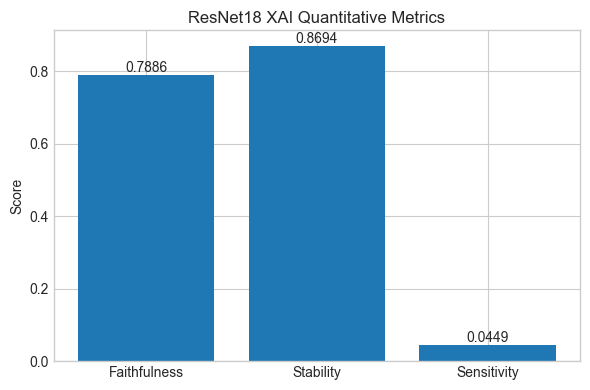

In [36]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")

metrics_path = PROJECT_ROOT / "results" / "metrics" / "resnet18_xai_quant_metrics.json"
with open(metrics_path, "r") as f:
    m = json.load(f)

print(json.dumps(m, indent=2))

labels = ["Faithfulness", "Stability", "Sensitivity"]
values = [
    m["faithfulness_mean_drop"],
    m["stability_mean_cosine"],
    m["sensitivity_mean_top_minus_random"],
]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values)
plt.title("ResNet18 XAI Quantitative Metrics")
plt.ylabel("Score")
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


   y_true            class_name  total  correct  accuracy
3       3               Highway    375      327  0.872000
6       6         PermanentCrop    375      331  0.882667
5       5               Pasture    300      276  0.920000
0       0            AnnualCrop    450      428  0.951111
2       2  HerbaceousVegetation    450      428  0.951111
8       8                 River    375      360  0.960000
9       9               SeaLake    450      434  0.964444
4       4            Industrial    375      362  0.965333
7       7           Residential    450      444  0.986667
1       1                Forest    450      447  0.993333


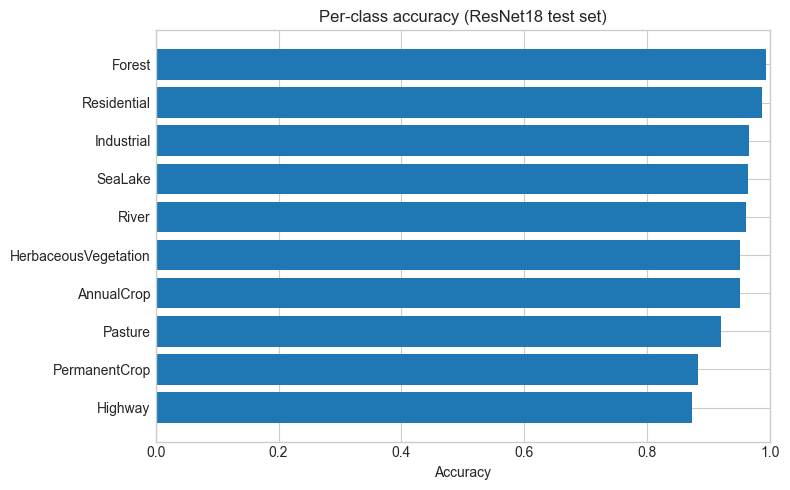


Top confusion pairs:
    y_true             true_name  y_pred             pred_name  size
19       3               Highway       8                 River    38
32       6         PermanentCrop       2  HerbaceousVegetation    27
31       6         PermanentCrop       0            AnnualCrop    12
41       8                 River       3               Highway     9
12       2  HerbaceousVegetation       6         PermanentCrop     9
44       9               SeaLake       1                Forest     8
25       5               Pasture       0            AnnualCrop     8
3        0            AnnualCrop       6         PermanentCrop     8
27       5               Pasture       2  HerbaceousVegetation     7
21       4            Industrial       3               Highway     5
29       5               Pasture       6         PermanentCrop     4
18       3               Highway       6         PermanentCrop     4
16       3               Highway       2  HerbaceousVegetation     4
2        0  

In [37]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")

pred_path = PROJECT_ROOT / "results" / "metrics" / "resnet18_test_predictions.csv"
map_path = PROJECT_ROOT / "data" / "splits" / "class_mapping.json"

if not pred_path.exists():
    raise FileNotFoundError(f"Missing predictions file: {pred_path}")
if not map_path.exists():
    raise FileNotFoundError(f"Missing class mapping file: {map_path}")

df = pd.read_csv(pred_path)

with open(map_path, "r") as f:
    cm = json.load(f)

# robust idx->name mapping
if all(str(k).isdigit() for k in cm.keys()):
    idx_to_name = {int(k): v for k, v in cm.items()}
elif all(isinstance(v, int) for v in cm.values()):
    idx_to_name = {v: k for k, v in cm.items()}
elif "idx_to_class" in cm:
    idx_to_name = {int(k): v for k, v in cm["idx_to_class"].items()}
else:
    idx_to_name = {i: str(i) for i in sorted(df["y_true"].unique())}

# class-wise accuracy
per_class = (
    df.groupby("y_true", as_index=False)
      .agg(total=("y_true", "size"), correct=("is_correct", "sum"))
)
per_class["accuracy"] = per_class["correct"] / per_class["total"]
per_class["class_name"] = per_class["y_true"].map(idx_to_name)
per_class = per_class.sort_values("accuracy", ascending=True)

print(per_class[["y_true", "class_name", "total", "correct", "accuracy"]])

plt.figure(figsize=(8, 5))
plt.barh(per_class["class_name"], per_class["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Per-class accuracy (ResNet18 test set)")
plt.tight_layout()
plt.show()

# top confusion pairs
conf = (
    df.loc[~df["is_correct"]]
      .groupby(["y_true", "y_pred"], as_index=False)
      .size()
      .sort_values("size", ascending=False)
      .head(15)
)
conf["true_name"] = conf["y_true"].map(idx_to_name)
conf["pred_name"] = conf["y_pred"].map(idx_to_name)

print("\nTop confusion pairs:")
print(conf[["y_true", "true_name", "y_pred", "pred_name", "size"]])


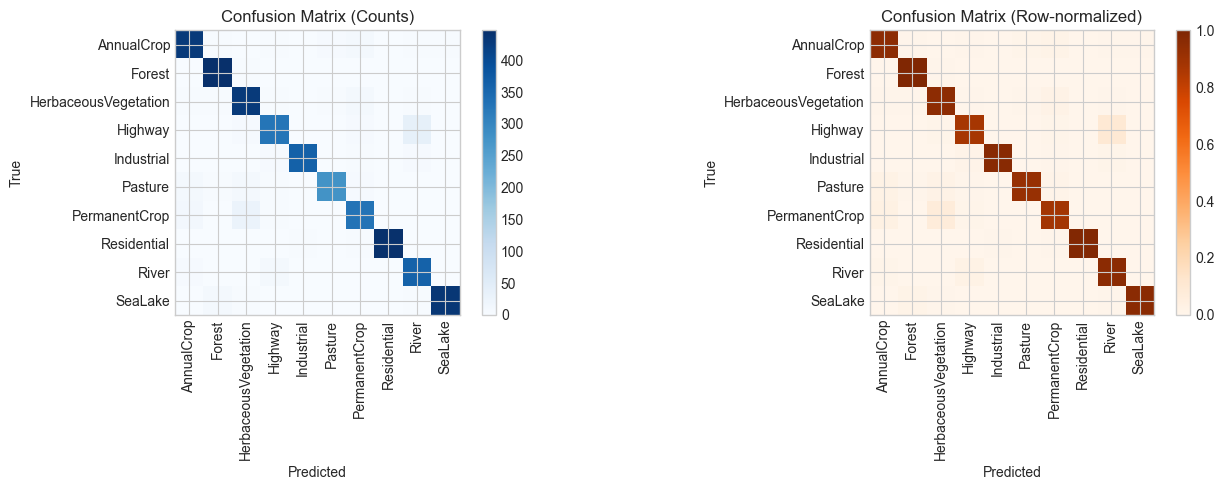

Saved: /Users/yashchourasia/Desktop/dissertation/yc432/results/figures/resnet18_confusion_matrix_counts_norm.png


In [38]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")

pred_path = PROJECT_ROOT / "results" / "metrics" / "resnet18_test_predictions.csv"
map_path = PROJECT_ROOT / "data" / "splits" / "class_mapping.json"

df = pd.read_csv(pred_path)

with open(map_path, "r") as f:
    cm = json.load(f)

# robust idx->name mapping
if all(str(k).isdigit() for k in cm.keys()):
    idx_to_name = {int(k): v for k, v in cm.items()}
elif all(isinstance(v, int) for v in cm.values()):
    idx_to_name = {v: k for k, v in cm.items()}
elif "idx_to_class" in cm:
    idx_to_name = {int(k): v for k, v in cm["idx_to_class"].items()}
else:
    idx_to_name = {i: str(i) for i in sorted(df["y_true"].unique())}

classes = sorted(idx_to_name.keys())
labels = [idx_to_name[i] for i in classes]

cm_counts = pd.crosstab(df["y_true"], df["y_pred"]).reindex(index=classes, columns=classes, fill_value=0)
cm_norm = cm_counts.div(cm_counts.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cm_counts.values, cmap="Blues")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, rotation=90)
axes[0].set_yticks(range(len(labels))); axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm.values, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Row-normalized)")
axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=90)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# save figure
save_path = PROJECT_ROOT / "results" / "figures" / "resnet18_confusion_matrix_counts_norm.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print(f"Saved: {save_path}")


Overall accuracy: 0.9474
Macro F1: 0.9457
   class_idx            class_name  precision    recall        f1  support
6          6         PermanentCrop   0.916898  0.882667  0.899457      375
3          3               Highway   0.928977  0.872000  0.899587      375
8          8                 River   0.878049  0.960000  0.917197      375
2          2  HerbaceousVegetation   0.906780  0.951111  0.928416      450
5          5               Pasture   0.968421  0.920000  0.943590      300
0          0            AnnualCrop   0.936543  0.951111  0.943771      450
4          4            Industrial   0.989071  0.965333  0.977058      375
9          9               SeaLake   0.990868  0.964444  0.977477      450
1          1                Forest   0.967532  0.993333  0.980263      450
7          7           Residential   0.993289  0.986667  0.989967      450
Saved: /Users/yashchourasia/Desktop/dissertation/yc432/results/metrics/resnet18_classwise_metrics.csv


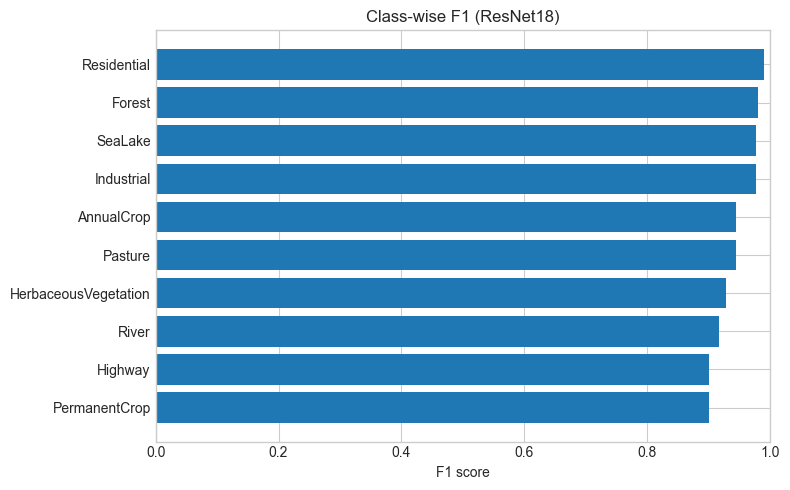

In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")

pred_path = PROJECT_ROOT / "results" / "metrics" / "resnet18_test_predictions.csv"
map_path = PROJECT_ROOT / "data" / "splits" / "class_mapping.json"

df = pd.read_csv(pred_path)

with open(map_path, "r") as f:
    cm = json.load(f)

# robust idx->name mapping
if all(str(k).isdigit() for k in cm.keys()):
    idx_to_name = {int(k): v for k, v in cm.items()}
elif all(isinstance(v, int) for v in cm.values()):
    idx_to_name = {v: k for k, v in cm.items()}
elif "idx_to_class" in cm:
    idx_to_name = {int(k): v for k, v in cm["idx_to_class"].items()}
else:
    idx_to_name = {i: str(i) for i in sorted(df["y_true"].unique())}

classes = sorted(idx_to_name.keys())
labels = [idx_to_name[i] for i in classes]

p, r, f1, s = precision_recall_fscore_support(
    df["y_true"], df["y_pred"], labels=classes, zero_division=0
)

metrics_df = pd.DataFrame({
    "class_idx": classes,
    "class_name": labels,
    "precision": p,
    "recall": r,
    "f1": f1,
    "support": s,
}).sort_values("f1", ascending=True)

acc = accuracy_score(df["y_true"], df["y_pred"])
macro_f1 = metrics_df["f1"].mean()

print(f"Overall accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(metrics_df)

out_csv = PROJECT_ROOT / "results" / "metrics" / "resnet18_classwise_metrics.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# plot F1 per class
plt.figure(figsize=(8, 5))
plt.barh(metrics_df["class_name"], metrics_df["f1"])
plt.xlim(0, 1)
plt.xlabel("F1 score")
plt.title("Class-wise F1 (ResNet18)")
plt.tight_layout()
plt.show()


Showing and saving 15 misclassified examples...



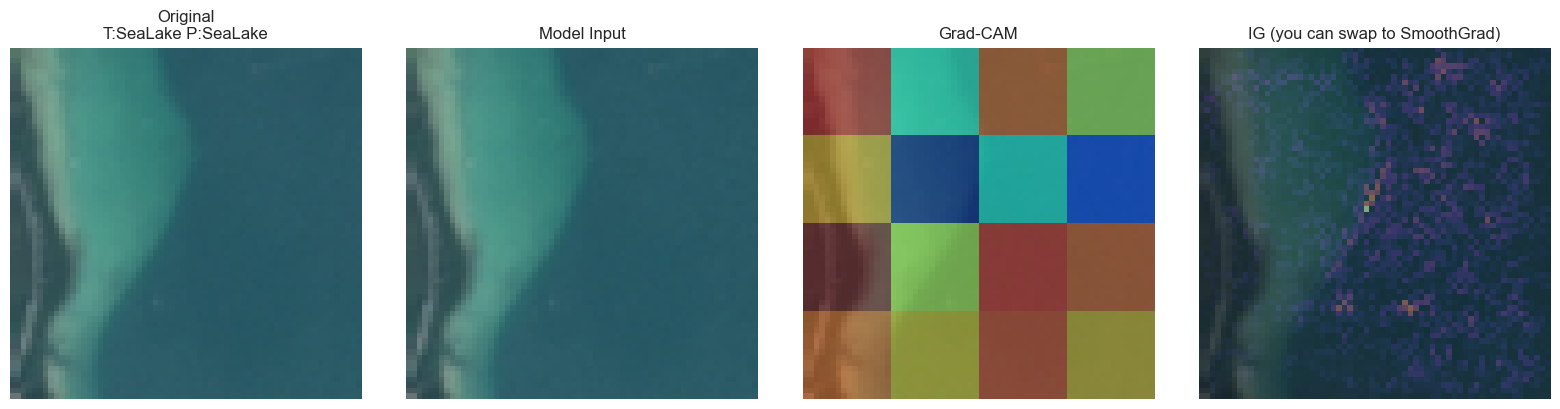

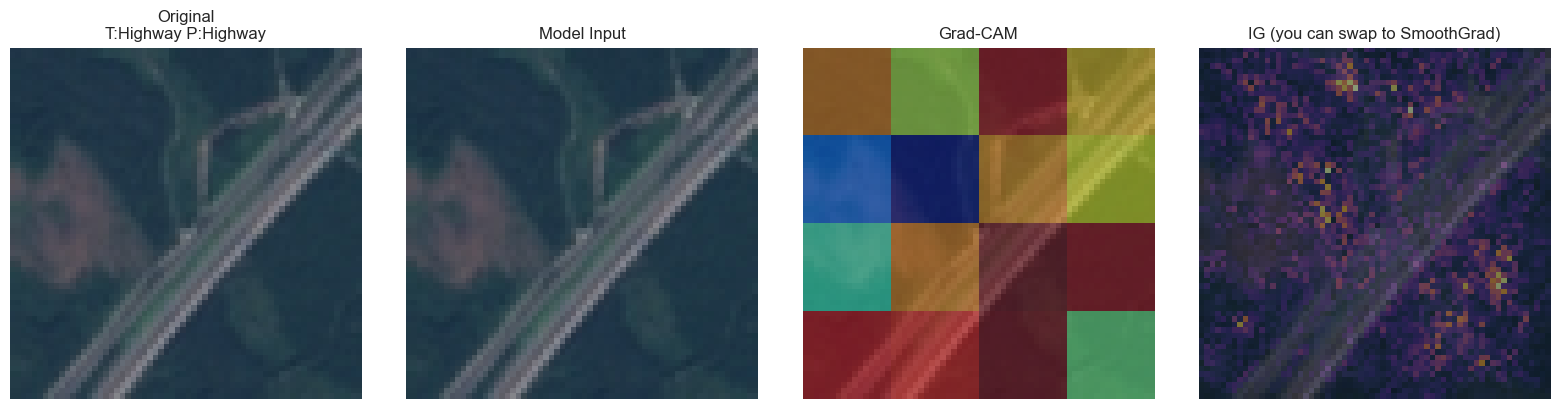

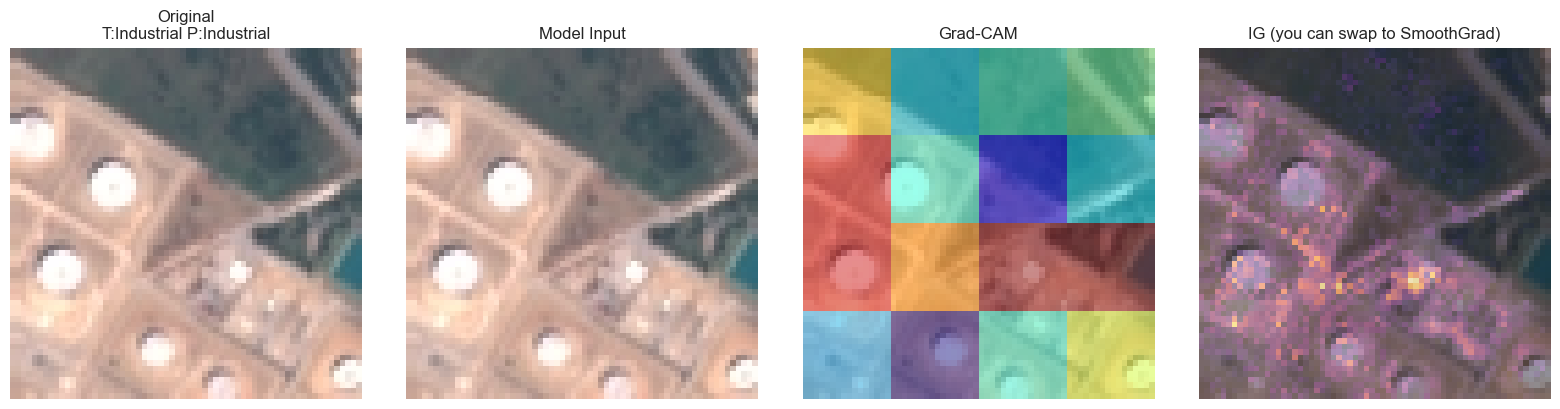

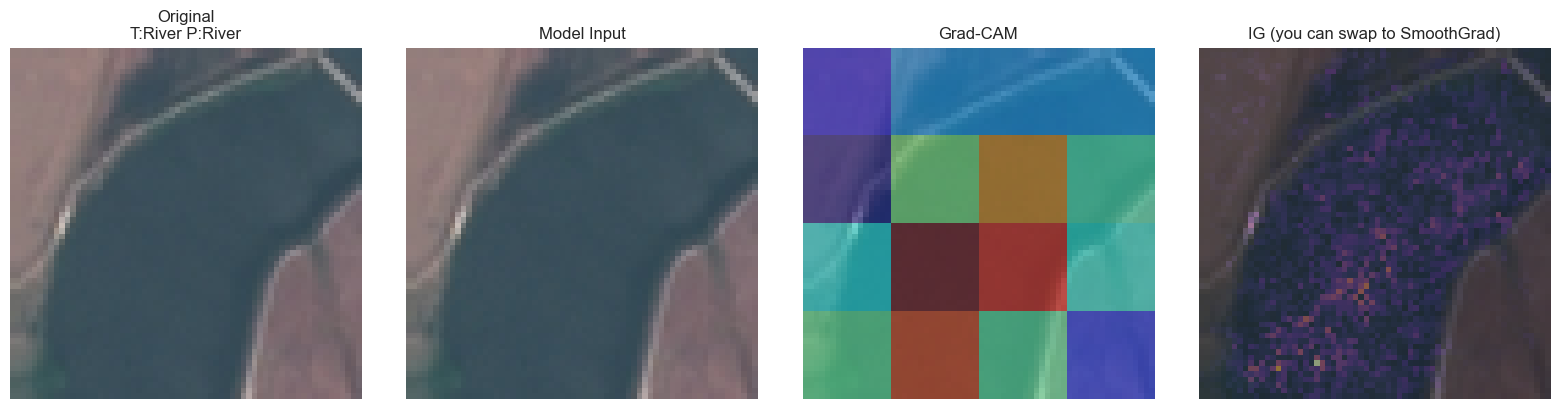

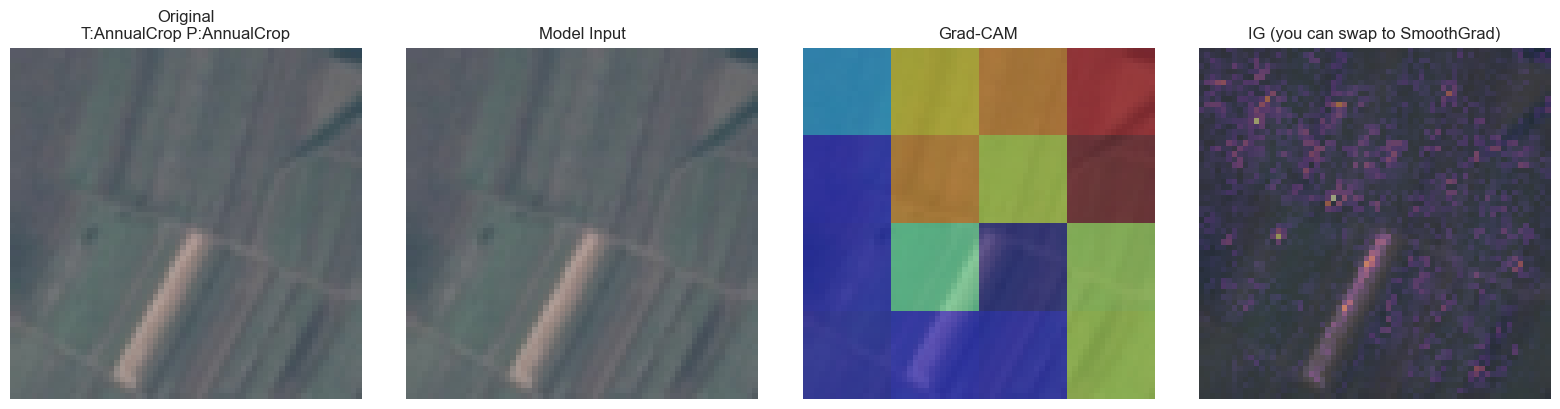

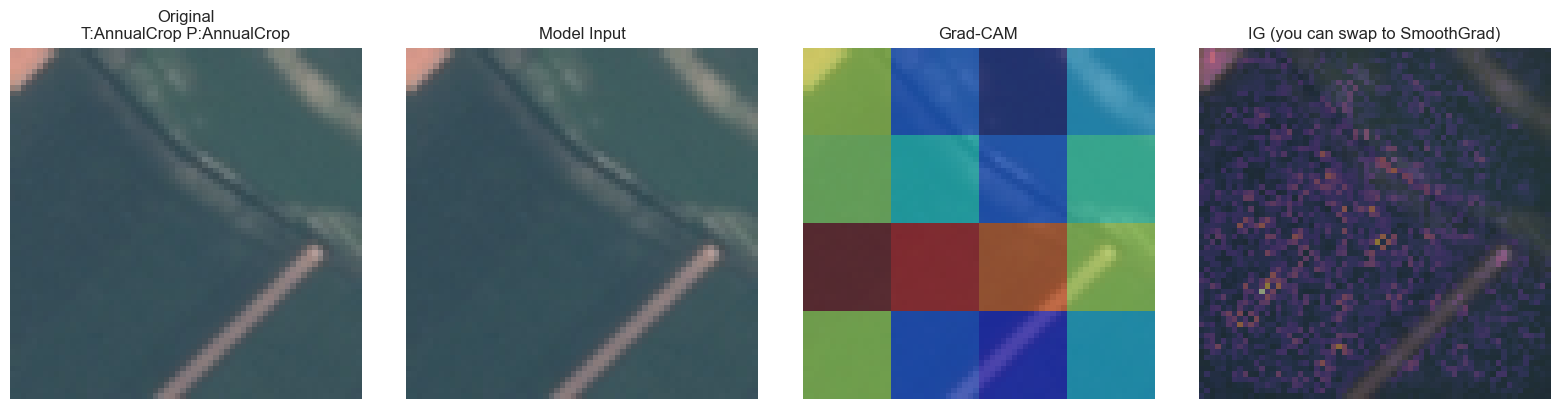

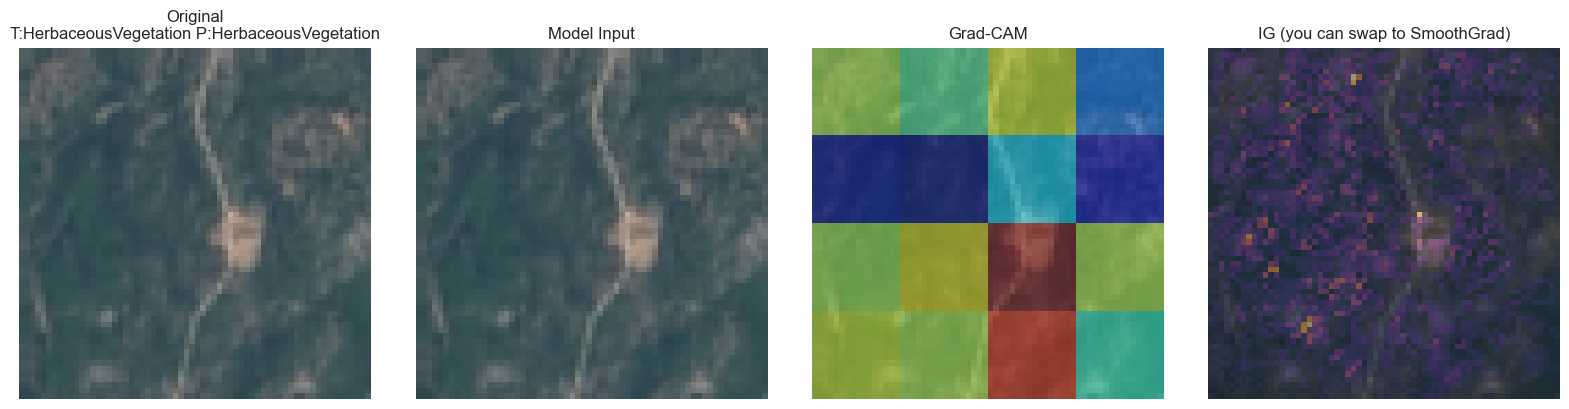

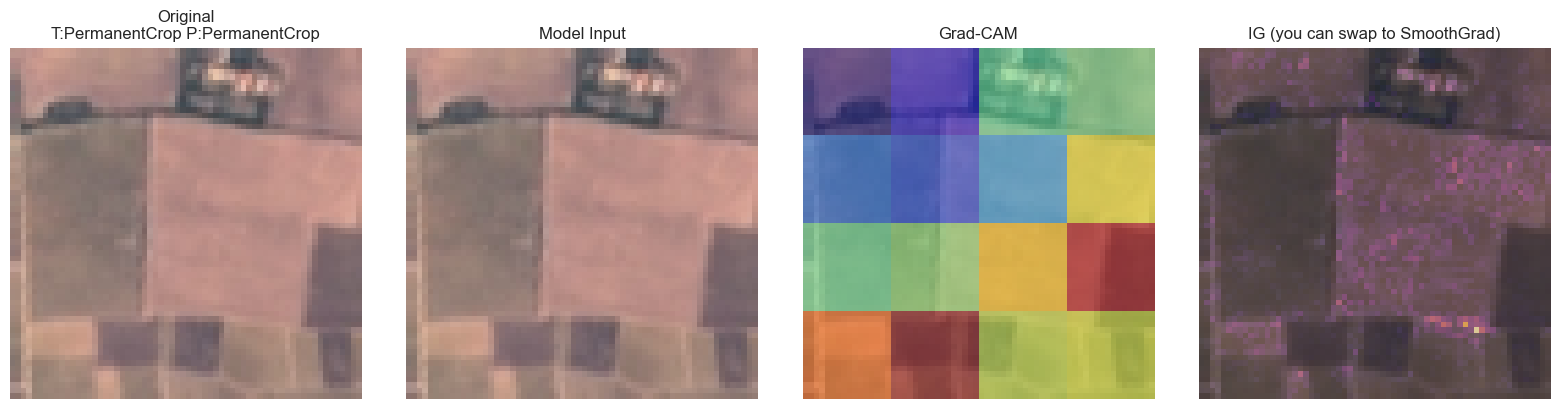

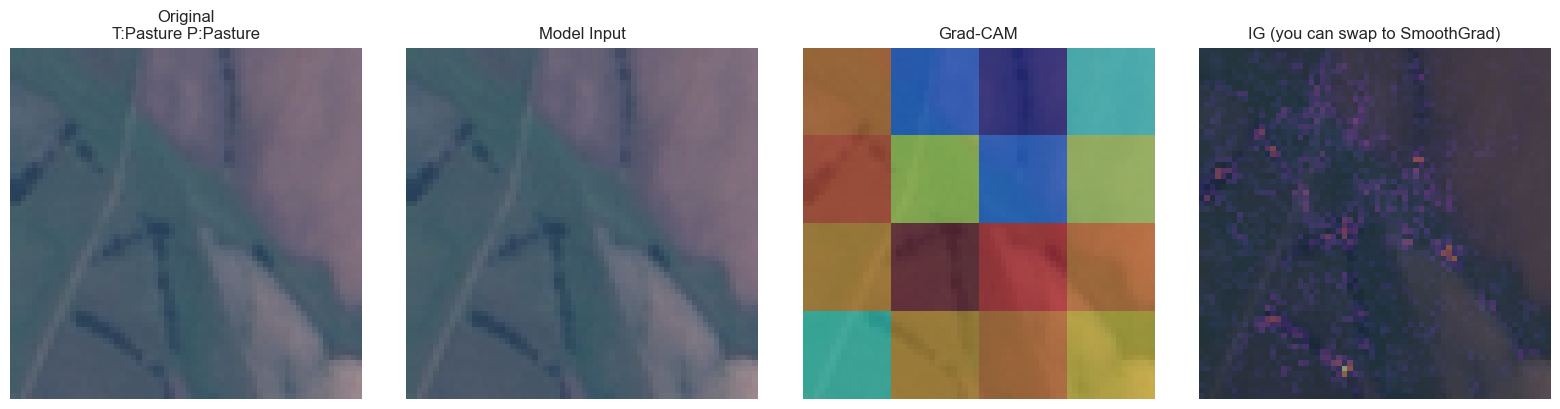

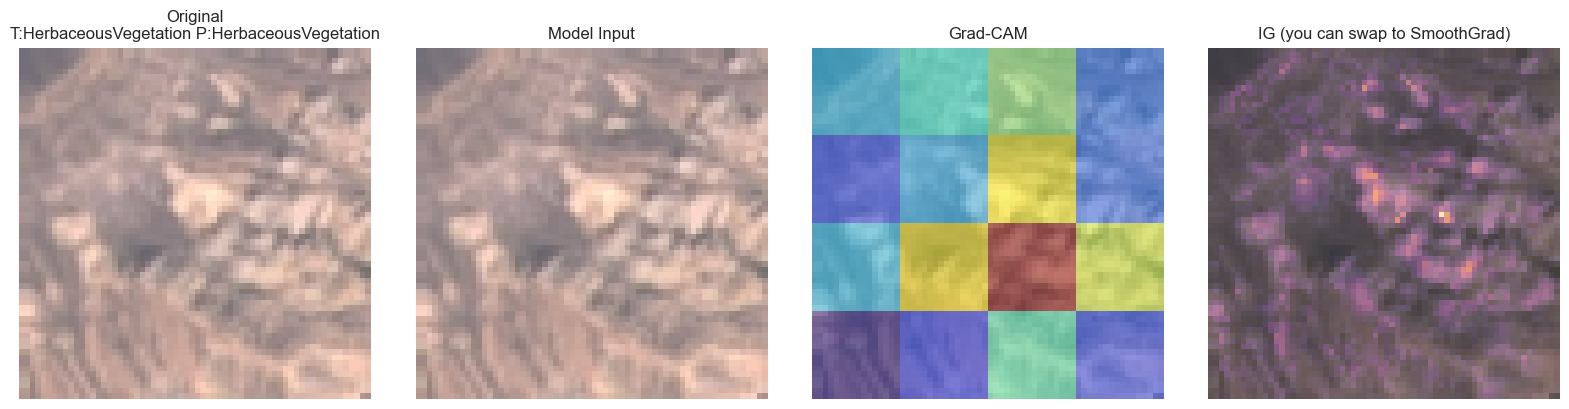

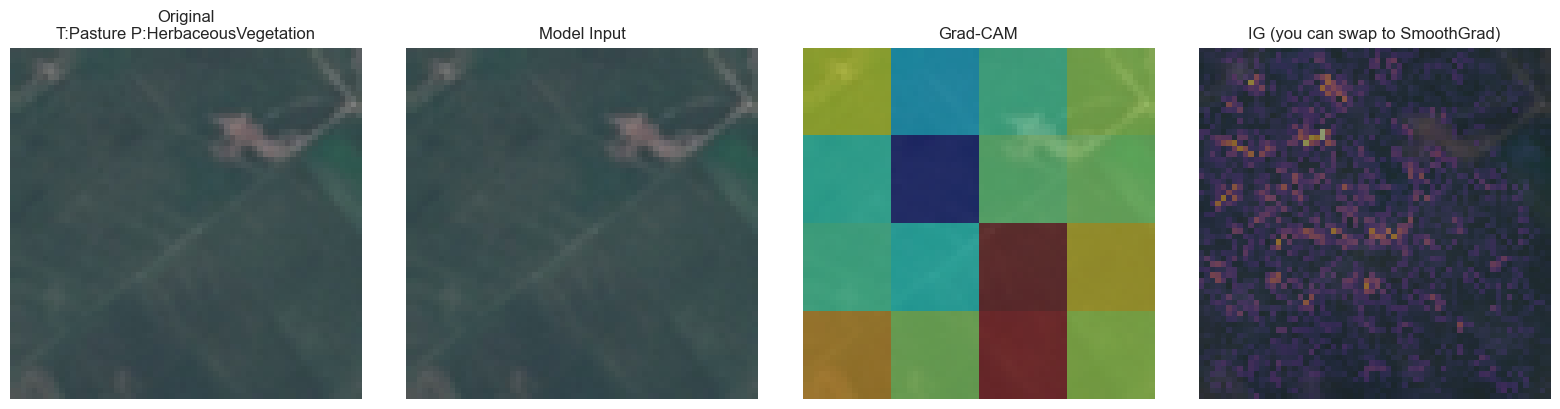

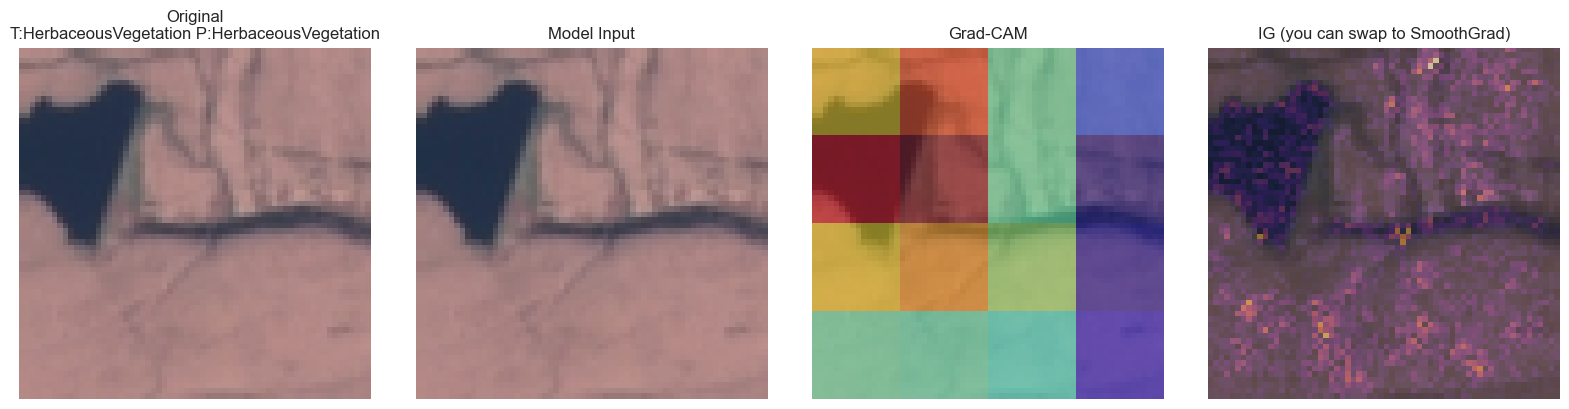

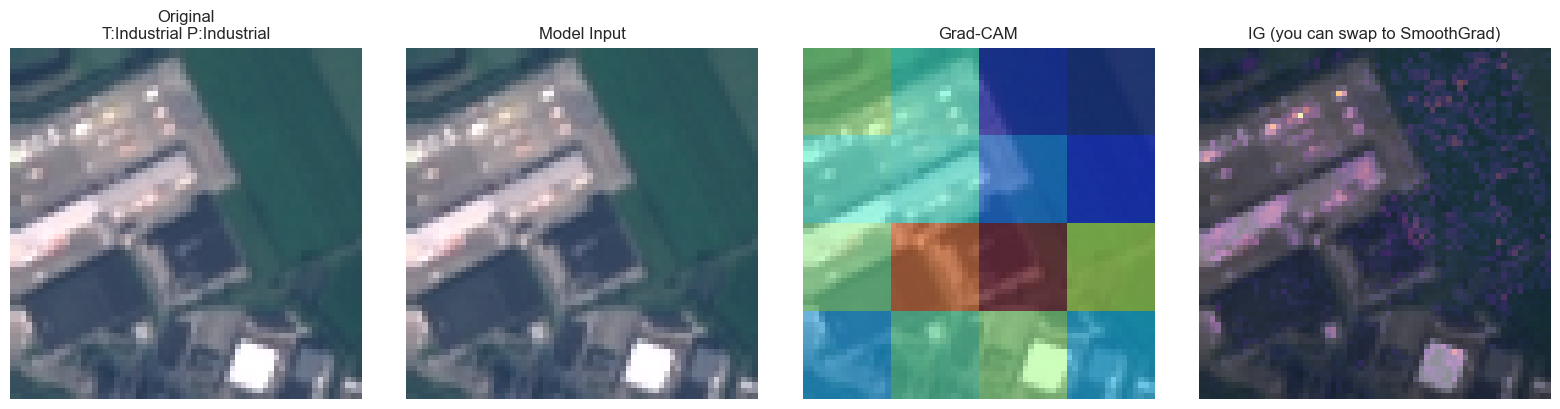

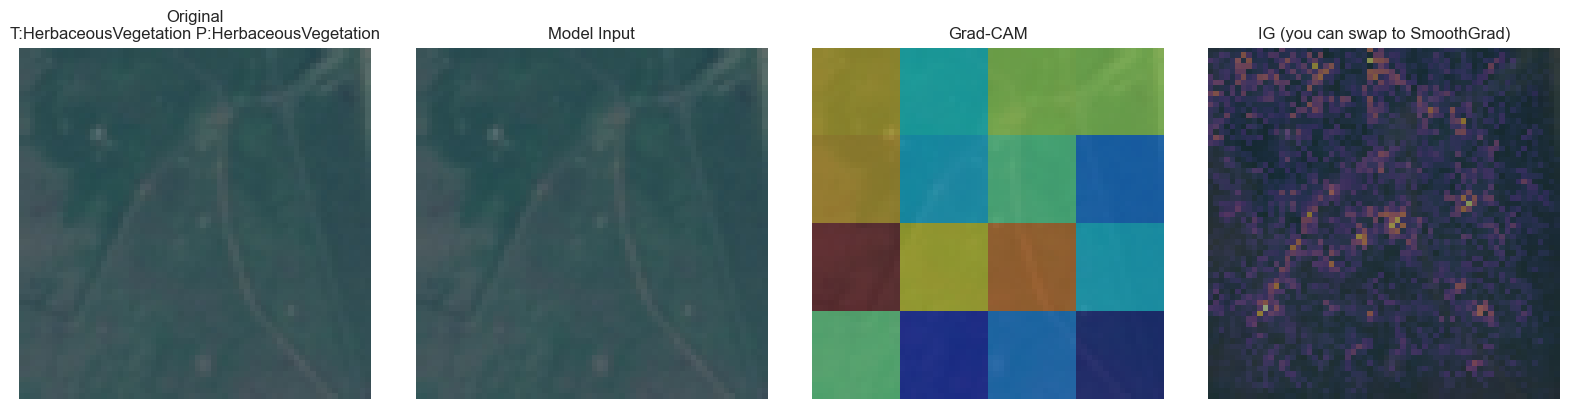

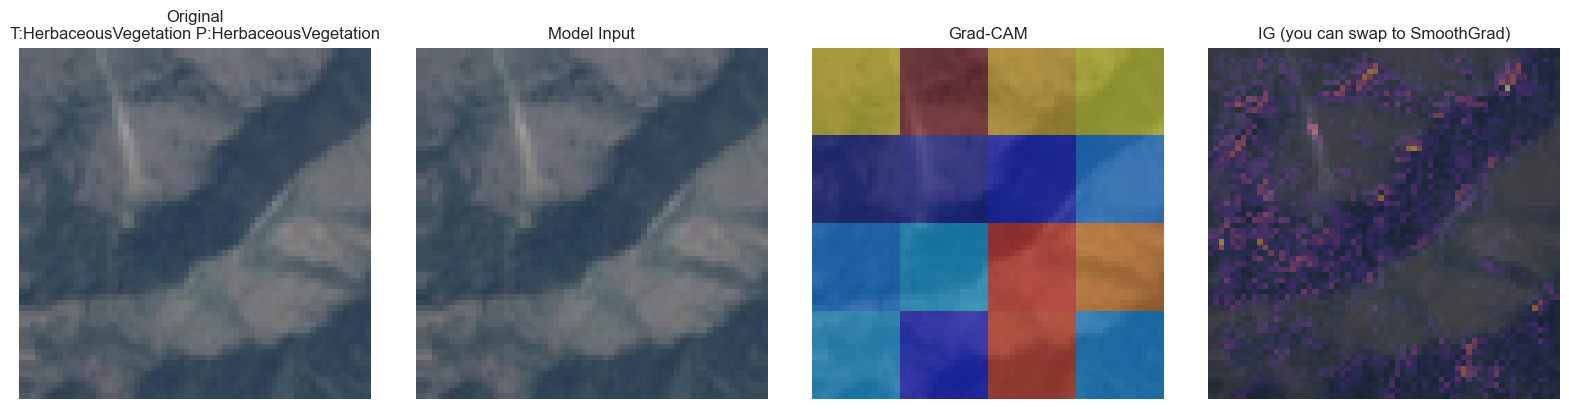

Saved misclassification XAI images to: results/failure_cases
Saved image count: 15
First saved files:
    misclassified_xai_00.png
    misclassified_xai_01.png
    misclassified_xai_02.png
    misclassified_xai_03.png
    misclassified_xai_04.png
    misclassified_xai_05.png
    misclassified_xai_06.png
    misclassified_xai_07.png
    misclassified_xai_08.png
    misclassified_xai_09.png


In [40]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18
from captum.attr import LayerGradCam, LayerAttribution, IntegratedGradients, NoiseTunnel

# ------------------ recovery ------------------
PROJECT_ROOT = Path(".")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model
if "model" not in globals():
    ckpt = PROJECT_ROOT / "checkpoints" / "resnet18_best_10ep.pth"
    if not ckpt.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt}")

    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model = model.to(device)

model.eval()

# mis_df
if "mis_df" not in globals():
    mis_csv = PROJECT_ROOT / "results" / "failure_cases" / "misclassified_samples.csv"
    if not mis_csv.exists():
        raise FileNotFoundError(f"Missing: {mis_csv}")
    mis_df = pd.read_csv(mis_csv)

    # Normalize stale absolute paths from older runs (e.g., /home/yash/...) to current machine paths
    candidate_bases = [
        PROJECT_ROOT / "data" / "2750",
        PROJECT_ROOT / "data" / "EuroSAT",
        PROJECT_ROOT / "EuroSAT",
    ]

    def resolve_filepath(fp: str) -> str:
        p = Path(str(fp))
        if p.exists():
            return str(p)

        parts = p.parts
        for marker in ("EuroSAT", "2750"):
            if marker in parts:
                rel = Path(*parts[parts.index(marker) + 1:])
                for base in candidate_bases:
                    cand = base / rel
                    if cand.exists():
                        return str(cand)

        # Fallback: class_name/filename columns if present
        cls = None
        name = None
        if "class_name" in mis_df.columns:
            cls = mis_df.loc[idx, "class_name"]
        if "filename" in mis_df.columns:
            name = mis_df.loc[idx, "filename"]
        if cls and name:
            for base in candidate_bases:
                cand = base / str(cls) / str(name)
                if cand.exists():
                    return str(cand)

        return str(p)

    for idx in mis_df.index:
        mis_df.at[idx, "filepath"] = resolve_filepath(mis_df.at[idx, "filepath"])

# class names
class_names = None
class_map_path = PROJECT_ROOT / "data" / "splits" / "class_mapping.json"
if class_map_path.exists():
    with open(class_map_path, "r") as f:
        m = json.load(f)
    inv = {v: k for k, v in m.items()}
    class_names = [inv[i] for i in sorted(inv)]

# transforms
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

def denorm(x):
    return torch.clamp(x * std + mean, 0, 1)

def norm_map(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)

# explainers
gradcam = LayerGradCam(model, model.layer3[-1].conv2)  # better for 64x64
ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)

save_dir = PROJECT_ROOT / "results" / "failure_cases"
save_dir.mkdir(parents=True, exist_ok=True)

N = min(15, len(mis_df))
saved_files = []

print(f"Showing and saving {N} misclassified examples...\n")

for i in range(N):
    row = mis_df.iloc[i]
    img_path = row["filepath"]

    raw_img = Image.open(img_path).convert("RGB")
    x = eval_transform(raw_img).unsqueeze(0).to(device)

    # labels
    y_true = int(row["y_true"]) if "y_true" in row else -1
    with torch.no_grad():
        y_pred = int(model(x).argmax(dim=1).item())

    # Grad-CAM
    cam = gradcam.attribute(x, target=y_pred)
    cam = LayerAttribution.interpolate(cam, (64, 64)).squeeze().detach().cpu().numpy()
    if cam.ndim == 3:
        cam = cam.mean(axis=0)
    cam = norm_map(cam)

    # IG
    baseline = torch.zeros_like(x)
    ig_attr = ig.attribute(x, baselines=baseline, target=y_pred, n_steps=50)
    ig_map = np.abs(ig_attr.squeeze().detach().cpu().numpy()).mean(axis=0)
    ig_map = norm_map(ig_map)

    # SmoothGrad (on IG)
    sg_attr = nt.attribute(
        x, nt_type="smoothgrad", nt_samples=25, stdevs=0.1,
        baselines=baseline, target=y_pred, n_steps=25
    )
    sg_map = np.abs(sg_attr.squeeze().detach().cpu().numpy()).mean(axis=0)
    sg_map = norm_map(sg_map)

    model_img = denorm(x[0]).detach().cpu().permute(1, 2, 0).numpy()

    t_name = class_names[y_true] if (class_names is not None and y_true >= 0) else str(y_true)
    p_name = class_names[y_pred] if class_names is not None else str(y_pred)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(raw_img)
    axes[0].set_title(f"Original\nT:{t_name} P:{p_name}")
    axes[0].axis("off")

    axes[1].imshow(model_img)
    axes[1].set_title("Model Input")
    axes[1].axis("off")

    axes[2].imshow(model_img)
    axes[2].imshow(cam, cmap="jet", alpha=0.45)
    axes[2].set_title("Grad-CAM")
    axes[2].axis("off")

    axes[3].imshow(model_img)
    axes[3].imshow(ig_map, cmap="inferno", alpha=0.45)
    axes[3].set_title("IG (you can swap to SmoothGrad)")
    axes[3].axis("off")

    plt.tight_layout()
    out_path = save_dir / f"misclassified_xai_{i:02d}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")

    # IMPORTANT: show inline
    plt.show()
    plt.close(fig)

    saved_files.append(out_path.name)

print(f"Saved misclassification XAI images to: {save_dir}")
print(f"Saved image count: {len(saved_files)}")
print("First saved files:")
for name in saved_files[:10]:
    print("   ", name)



In [41]:
import json
import numpy as np
import torch
from pathlib import Path
from captum.attr import IntegratedGradients
import pandas as pd
from PIL import Image
from torchvision import transforms

# ------------------ recovery ------------------
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(".")
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if "model" not in globals():
    raise NameError("model not found. Run model-restore cell first.")

# test_loader recovery (if missing)
if "test_loader" not in globals():
    from torch.utils.data import Dataset, DataLoader

    test_csv = PROJECT_ROOT / "data" / "splits" / "test.csv"
    df_test = pd.read_csv(test_csv)
    label_col = "class_idx" if "class_idx" in df_test.columns else "label"

    eval_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    class EuroSATTestDataset(Dataset):
        def __init__(self, df, transform):
            self.df = df.reset_index(drop=True)
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            x = Image.open(row["filepath"]).convert("RGB")
            y = int(row[label_col])
            return self.transform(x), y

    test_loader = DataLoader(
        EuroSATTestDataset(df_test, eval_transform),
        batch_size=64,
        shuffle=False,
        num_workers=0,  # safe
        pin_memory=torch.cuda.is_available(),
    )

model.eval()
ig = IntegratedGradients(model)

# ------------------ helper functions ------------------
def norm_map(m: torch.Tensor) -> torch.Tensor:
    m = m - m.min()
    return m / (m.max() + 1e-8)

def ig_map_for_pred(x: torch.Tensor, pred_cls: int, n_steps: int = 24) -> torch.Tensor:
    baseline = torch.zeros_like(x)
    attr = ig.attribute(x, baselines=baseline, target=pred_cls, n_steps=n_steps)
    # [1,3,H,W] -> [H,W]
    m = attr.abs().mean(dim=1).squeeze(0)
    return norm_map(m)

def topk_mask(m: torch.Tensor, frac: float = 0.20) -> torch.Tensor:
    flat = m.flatten()
    k = max(1, int(frac * flat.numel()))
    idx = torch.topk(flat, k).indices
    mask = torch.zeros_like(flat, dtype=torch.bool)
    mask[idx] = True
    return mask.view_as(m)

def random_mask_like(m: torch.Tensor, frac: float = 0.20) -> torch.Tensor:
    flat_n = m.numel()
    k = max(1, int(frac * flat_n))
    idx = torch.randperm(flat_n, device=m.device)[:k]
    mask = torch.zeros(flat_n, device=m.device, dtype=torch.bool)
    mask[idx] = True
    return mask.view_as(m)

def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.flatten()
    b = b.flatten()
    return float(torch.dot(a, b) / (torch.norm(a) * torch.norm(b) + 1e-8))

# ------------------ metric loops ------------------
faithfulness = []  # confidence drop when top-attribution pixels removed
stability = []     # cosine similarity between attribution maps under slight noise
sensitivity = []   # (top-mask drop - random-mask drop)

max_samples = 120
processed = 0

for images, _ in test_loader:
    images = images.to(device)

    for j in range(images.size(0)):
        if processed >= max_samples:
            break

        x = images[j:j+1]

        with torch.no_grad():
            logits = model(x)
            pred_cls = int(logits.argmax(dim=1).item())
            prob = torch.softmax(logits, dim=1)[0, pred_cls].item()

        # Attribution map
        m = ig_map_for_pred(x, pred_cls, n_steps=24)

        # Top-k mask + random mask
        m_top = topk_mask(m, frac=0.20)
        m_rand = random_mask_like(m, frac=0.20)

        # Remove top-k important area
        x_top_removed = x.clone()
        x_top_removed[:, :, m_top] = 0.0
        with torch.no_grad():
            p_top = torch.softmax(model(x_top_removed), dim=1)[0, pred_cls].item()

        # Remove random area
        x_rand_removed = x.clone()
        x_rand_removed[:, :, m_rand] = 0.0
        with torch.no_grad():
            p_rand = torch.softmax(model(x_rand_removed), dim=1)[0, pred_cls].item()

        # Faithfulness + sensitivity
        drop_top = prob - p_top
        drop_rand = prob - p_rand
        faithfulness.append(drop_top)
        sensitivity.append(drop_top - drop_rand)

        # Stability (small noise perturbation)
        noise = 0.03 * torch.randn_like(x)
        x_noisy = torch.clamp(x + noise, -3.0, 3.0)
        m_noisy = ig_map_for_pred(x_noisy, pred_cls, n_steps=16)
        stability.append(cosine_sim(m, m_noisy))

        processed += 1

    if processed >= max_samples:
        break

results = {
    "n_samples": int(processed),
    "faithfulness_mean_drop": float(np.mean(faithfulness)),
    "faithfulness_std": float(np.std(faithfulness)),
    "stability_mean_cosine": float(np.mean(stability)),
    "stability_std": float(np.std(stability)),
    "sensitivity_mean_top_minus_random": float(np.mean(sensitivity)),
    "sensitivity_std": float(np.std(sensitivity)),
}

metrics_path = PROJECT_ROOT / "results" / "metrics" / "resnet18_xai_quant_metrics.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2)

print(" XAI quantitative metrics computed")
print(json.dumps(results, indent=2))
print(f"Saved: {metrics_path}")


 XAI quantitative metrics computed
{
  "n_samples": 120,
  "faithfulness_mean_drop": 0.7885886523921869,
  "faithfulness_std": 0.37598267725848933,
  "stability_mean_cosine": 0.8721225827932357,
  "stability_std": 0.09355346547952319,
  "sensitivity_mean_top_minus_random": 0.03659261268176572,
  "sensitivity_std": 0.15089513279007807
}
Saved: results/metrics/resnet18_xai_quant_metrics.json
